# TCCT S87A - Seven-Branch Failure Audit (No Retuning)

S87 is already revealed and remains a valid blind failure. This audit reconstructs the same 392 worlds once, retaining raw observations so that raw-state separability, K=33 collisions, and frozen-policy coverage can be distinguished.

This is not a new blind test. It performs no training, K search, policy edit, candidate selection, export, or retuning. The original core, canonicalizer, intervention, topology, deduplication rule, and frozen candidate are hash-locked.

Use **Kernel -> Restart Kernel and Run All Cells**. The long cell should take roughly as long as S87 because it traces the same worlds once.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
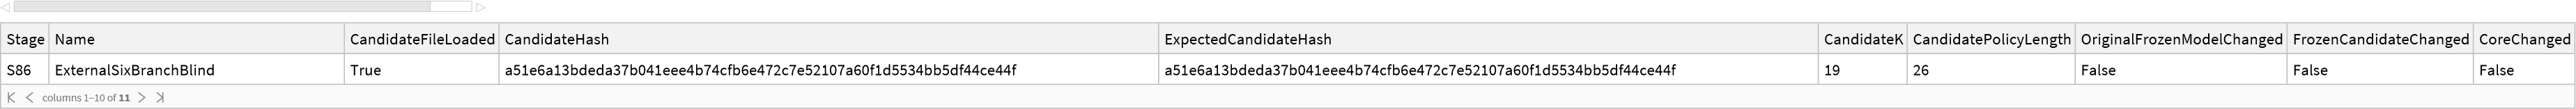

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S87, Name -> SevenBranchMixedInterventionBlind, 
 
>     CandidateFrozenBeforeTest -> True, 
 
>     CandidateHash -> 2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     ExpectedCandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, K -> 33, 
 
>     PolicyLength -> 39, BranchCount -> 7, Depths -> {47, 83}, SelectionRun -> False, 
 
>     PolicyEditApplied -> False, RetuningApplied -> False, 
 
>     S87LabelsUsedForSelection -> False, OriginalFrozenModelChanged -> False, 
 
>     BaseK19CandidateChanged -> False, CoreChanged -> False, 
 
>     DeduplicationMechanismChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 18], 
 
>    1], <||>]
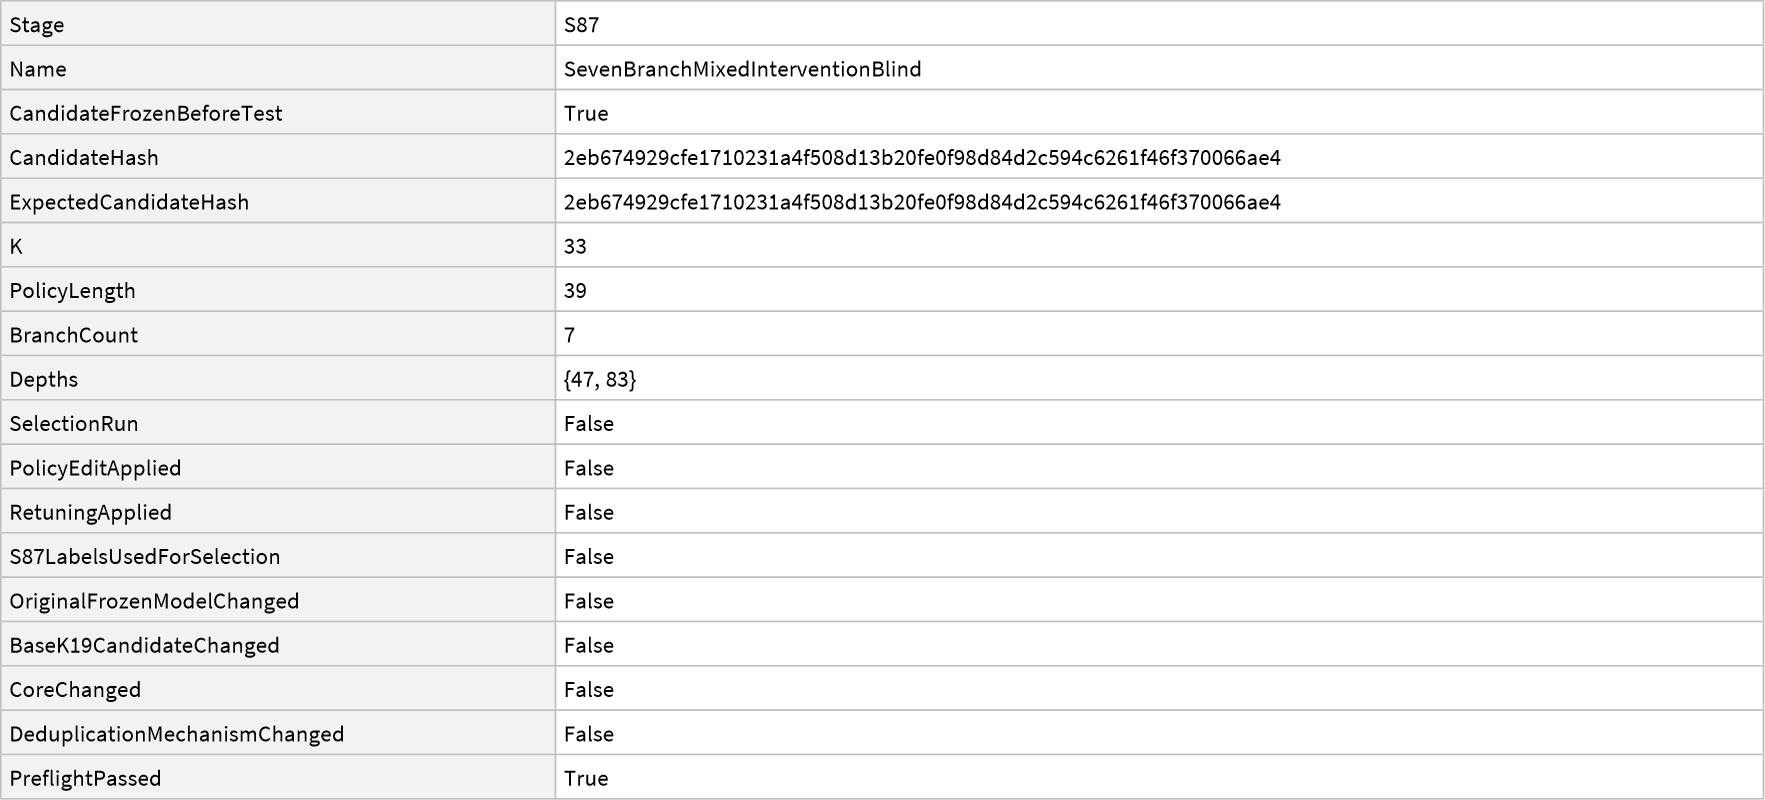

In [89]:
expectedK33CandidateHash87=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedBaseK19CandidateHash87=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";
expectedSelectionCertificateHash87=
"974c588337fbd9c3f51e9ea6847ba360dfc9dcf6fced751104f028987900ac5a";
expectedSelectionProtocolHash87=
"3faafbe4eef88369c32637b2b6b0825e288f6c40d7286db47e8739f083c3d309";
expectedSelectedResultHash87=
"cf6809b1fee65997fe95bdb28e6e3886e2a09f00ed9815ef0f6edff1117fe5ce";

k33CandidatePath87="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
oldK19CandidatePath87="E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[k33CandidatePath87],
Print["S87 aborted: frozen K33 candidate file is missing."];Abort[]
];

k33CandidateFileHashBefore87=FileHash[k33CandidatePath87,"SHA256"];
oldK19CandidateFileHashBefore87=If[
FileExistsQ[oldK19CandidatePath87],
FileHash[oldK19CandidatePath87,"SHA256"],
Missing["OldK19CandidateFileMissing"]
];

Clear[frozenCandidate86E];
Get[k33CandidatePath87];

candidateHashLoaded87=If[
AssociationQ[frozenCandidate86E],
Hash[Normal[frozenCandidate86E],"SHA256","HexString"],
Missing["K33CandidateNotLoaded"]
];
baseK19CandidateHashBefore87=Hash[
Normal[frozenCandidate83B],"SHA256","HexString"
];

ClearAll[CoreDefinitionBundle87];
CoreDefinitionBundle87[]:=CoreDefinitionBundle86[];

preflightPassed87=And[
TrueQ[preflightPassed86],
AssociationQ[frozenCandidate86E],
SameQ[candidateHashLoaded87,expectedK33CandidateHash87],
SameQ[baseK19CandidateHashBefore87,expectedBaseK19CandidateHash87],
SameQ[frozenCandidate86E["Stage"],"S86E"],
SameQ[frozenCandidate86E["Name"],"K33CrossArityCandidate"],
SameQ[frozenCandidate86E["BaseCandidateHash"],expectedBaseK19CandidateHash87],
SameQ[frozenCandidate86E["SelectionCertificateHash"],
expectedSelectionCertificateHash87],
SameQ[frozenCandidate86E["SelectionProtocolHash"],
expectedSelectionProtocolHash87],
SameQ[frozenCandidate86E["SelectedResultHash"],expectedSelectedResultHash87],
SameQ[frozenCandidate86E["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate86E["Representation"],"KExactRole"],
SameQ[frozenCandidate86E["K"],33],
SameQ[frozenCandidate86E["PolicyLength"],39],
SameQ[Length[frozenCandidate86E["Policy"]],39],
SameQ[frozenCandidate86E["CombinedDevelopmentScore"],552],
TrueQ[frozenCandidate86E["ExactNodeRoleUsed"]],
SameQ[frozenCandidate86E["TokenDeduplication"],"DeleteDuplicates"],
TrueQ[frozenCandidate86E["FrozenBeforeS87"]],
FileExistsQ[oldK19CandidatePath87]
];

expectedCandidateHash87=expectedK33CandidateHash87;
expectedCanonicalizerHash87=expectedCanonicalizerHash86;
expectedInterventionHash87=expectedInterventionHash86;

preflight87=<|
"Stage"->"S87",
"Name"->"SevenBranchMixedInterventionBlind",
"CandidateFrozenBeforeTest"->True,
"CandidateHash"->candidateHashLoaded87,
"ExpectedCandidateHash"->expectedK33CandidateHash87,
"K"->If[AssociationQ[frozenCandidate86E],frozenCandidate86E["K"],Missing[]],
"PolicyLength"->If[
AssociationQ[frozenCandidate86E],Length[frozenCandidate86E["Policy"]],Missing[]
],
"BranchCount"->7,
"Depths"->{47,83},
"SelectionRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"S87LabelsUsedForSelection"->False,
"OriginalFrozenModelChanged"->False,
"BaseK19CandidateChanged"->False,
"CoreChanged"->False,
"DeduplicationMechanismChanged"->False,
"PreflightPassed"->preflightPassed87
|>;

If[
!TrueQ[preflightPassed87],
Print[Dataset[{preflight87}]];
Print["S87 aborted: frozen K33 candidate or architecture mismatch."];
Abort[]
];

Dataset[{preflight87}]


Dataset[{<|Stage -> S87, Name -> SevenBranchMixedInterventionBlind, 
 
>     Candidate -> S86E-K33ExactRole, 
 
>     CandidateHash -> 2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     Depths -> {47, 83}, Topologies -> {DoubleDiamondIn, HierarchicalDiamondIn}, 
 
>     InterventionPairs -> {{1, 3}, {2, 4}, {3, 5}, {4, 6}, {5, 7}, {6, 1}, {7, 2}}, 
 
>     BranchCount -> 7, ExpectedScenarios -> 28, ExpectedWorldPairs -> 196, 
 
>     ExpectedWorlds -> 392, ExternalGrammar -> IndependentSevenBranchT87, 
 
>     Intervention -> OneRedundantPathCutPlusOneBranchStopPatch, 
 
>     QueryGrid -> AllSevenQueriesBeforeAndAfterMixedIntervention, 
 
>     ExpectedStopPatchedQueryPairs -> 28, ExpectedNonStopQueryPairs -> 168, 
 
>     TokenDeduplication -> DeleteDuplicatesAfterExactRoleCodePairing, 
 
>     CandidateFrozenBeforeProtocol -> True, CandidateSearchRun -> False, 
 
>     TrainingRun -> False, HistoricalRegressionRerun -> False, S83BlindRerun -> False, 
 
>     S84BlindRerun -> False, S85BlindRerun -> False, S83BDevelopmentRowsRerun -> False, 
 
>     S87LabelsUsedForSelection -> False, NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 0c6f158cf154f8a89618a41d25c3ff7fc6e37f2f5b2c1a4db31d32f1666512c1|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     28], 1], <||>]
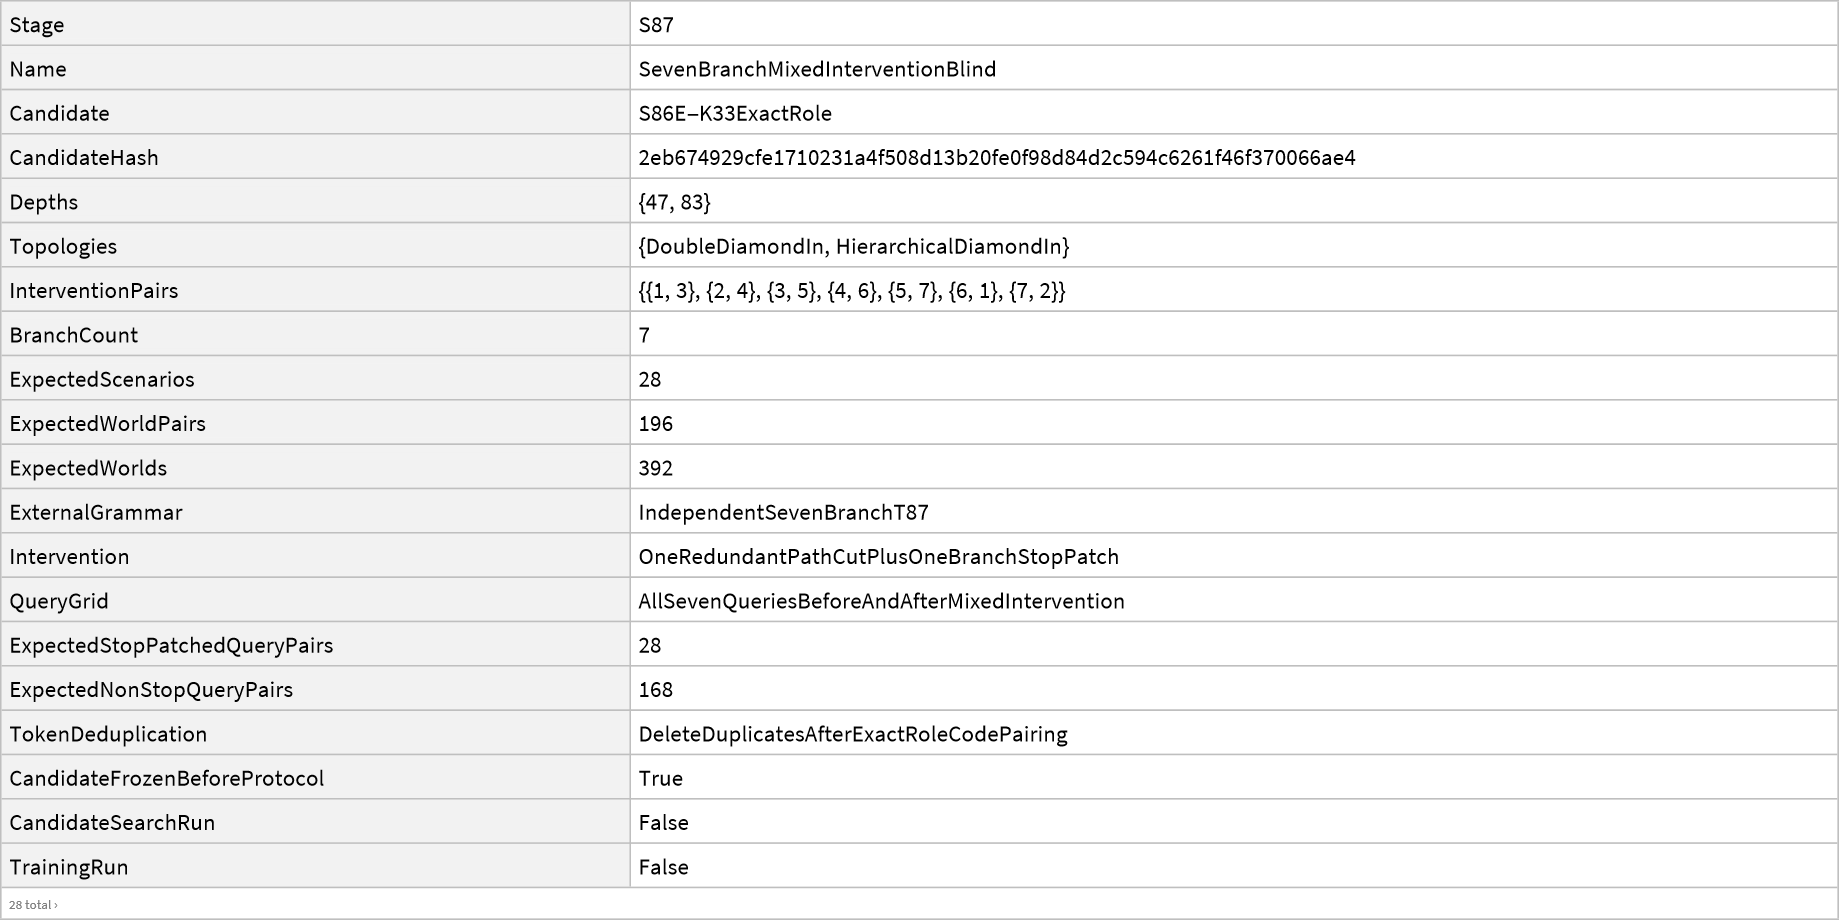

In [112]:
ClearAll[
T87,
Case87,
ReferenceAction87,
NodeRole87,
EncodePair87,
PredictTokens87,
SetAnswer87,
TopologyTransform87,
ExpectedContractions87,
BranchStopPatch87,
PathCutPatch87,
MixedPathCutStopPatch87,
PrepareWorld87,
PrepareScenario87,
S87TestDefinitionBundle
];


T87[
depth_Integer,
target_String,
answer_Integer,
seed_Integer,
branchCount_Integer
]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,branchCount}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dummy=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,branchCount]]];
main=Join[
P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,depth+1,ib+3000000]
];
perm=If[
target==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dummy]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,branchCount}
];
{{Union[e],q,K,v,c,f},answer}
];

Case87[depth_Integer,answer_Integer,target_String]:=
T87[depth,target,answer,87000000+100 depth,7];

ReferenceAction87[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,
correct,wrong,continueEdges,stopEdges
},
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],"Stop",
True,"Undefined"
]
];

NodeRole87[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
branchCount=Length[x[[6]]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair87[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S87BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate86E["EncoderParams"],
frozenCandidate86E["K"]
];
First[encoded["Codes"]]
];

PredictTokens87[tokens_List]:=If[
AnyTrue[tokens,MemberQ[frozenCandidate86E["Policy"],#]&],
"Continue",
"Stop"
];

SetAnswer87[c_List,answer_Integer]:={c[[1]],answer};

TopologyTransform87[topology_String,c_List]:=Switch[
topology,
"DoubleDiamondIn",DoubleDiamondIn79[c],
"HierarchicalDiamondIn",HierarchicalDiamondIn80[c],
_,$Failed
];

ExpectedContractions87[topology_String,baseCase_List]:=Switch[
topology,
"DoubleDiamondIn",2 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]
];

BranchStopPatch87[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
add={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

PathCutPatch87[c_List,branch_Integer]:=Module[
{x,e,m,cutEdge,remainingEdge},
x=c[[1]];
e=x[[1]];
m=x[[6,branch]];
cutEdge=DirectedEdge[m+9,m];
remainingEdge=DirectedEdge[m+19,m];
<|
"Remove"->{cutEdge},
"Add"->{},
"ValidOnInput"->And[
MemberQ[e,cutEdge],MemberQ[e,remainingEdge]
]
|>
];

MixedPathCutStopPatch87[c_List,interventionPair_List]:=Module[
{cutPart,stopPart,remove,add},
cutPart=PathCutPatch87[c,First[interventionPair]];
stopPart=BranchStopPatch87[c,Last[interventionPair]];
remove=DeleteDuplicates@Join[cutPart["Remove"],stopPart["Remove"]];
add=DeleteDuplicates@Join[cutPart["Add"],stopPart["Add"]];
<|
"Remove"->remove,
"Add"->add,
"CutBranch"->First[interventionPair],
"StopBranch"->Last[interventionPair],
"ComponentPatchesValid"->And[
TrueQ[cutPart["ValidOnInput"]],TrueQ[stopPart["ValidOnInput"]]
],
"NoCrossBranchConflict"->Intersection[remove,add]==={},
"ExpectedEditCount"->And[Length[remove]===4,Length[add]===3]
|>
];

PrepareWorld87[
topology_String,
depth_Integer,
interventionPair_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,tokens,prediction
},
topologyCase=TopologyTransform87[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions87[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole87[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair87[pair]
|>
],
packedNodes
];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
prediction=PredictTokens87[tokens];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction87[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],
"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"PolicyHitTokens"->Intersection[tokens,frozenCandidate86E["Policy"]],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];

PrepareScenario87[
topology_String,depth_Integer,interventionPair_List
]:=Module[
{
branchCount=7,seedCase,patch,hybridSeed,baseWorlds,hybridWorlds,
worldPairs,baseGraphHashes,hybridGraphHashes
},
seedCase=Case87[depth,1,"Continue"];
patch=MixedPathCutStopPatch87[seedCase,interventionPair];
hybridSeed=ApplyEdgePatch81[seedCase,patch];
If[SameQ[hybridSeed,$Failed],Return[$Failed]];
baseWorlds=Table[
PrepareWorld87[
topology,depth,interventionPair,"Baseline",answer,"Continue",
SetAnswer87[seedCase,answer]
],
{answer,Range[branchCount]}
];
hybridWorlds=Table[
PrepareWorld87[
topology,depth,interventionPair,"MixedPathCutStopIntervention",answer,
If[SameQ[answer,Last[interventionPair]],"Stop","Continue"],
SetAnswer87[hybridSeed,answer]
],
{answer,Range[branchCount]}
];
worldPairs=MapThread[
Function[{base,hybrid},
<|
"Answer"->base["Answer"],
"StopPatchedQuery"->SameQ[Last[interventionPair],base["Answer"]],
"SameQuery"->SameQ[base["Answer"],hybrid["Answer"]],
"ReferenceRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Stop"]
],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Continue"]
]
],
"PredictionRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Stop"]
],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Continue"]
]
],
"PairCorrect"->And[TrueQ[base["Correct"]],TrueQ[hybrid["Correct"]]],
"BaselineWorld"->base,
"InterventionWorld"->hybrid
|>
],
{baseWorlds,hybridWorlds}
];
baseGraphHashes=Lookup[baseWorlds,"TopologyGraphHash"];
hybridGraphHashes=Lookup[hybridWorlds,"TopologyGraphHash"];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"MixedInterventionValidity"->patch["ComponentPatchesValid"],
"MixedInterventionNoConflict"->patch["NoCrossBranchConflict"],
"MixedEditCountCorrect"->patch["ExpectedEditCount"],
"BaselineSameGraphAcrossQueries"->SameQ@@baseGraphHashes,
"InterventionSameGraphAcrossQueries"->SameQ@@hybridGraphHashes,
"MixedInterventionChangesGraph"->UnsameQ[First[baseGraphHashes],First[hybridGraphHashes]],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,"PredictionRelationCorrect"],
"AllFourteenWorldsCorrect"->And@@Join[
Lookup[baseWorlds,"Correct"],Lookup[hybridWorlds,"Correct"]
],
"WorldPairs"->worldPairs,
"BaselineWorlds"->baseWorlds,
"InterventionWorlds"->hybridWorlds
|>
];

S87TestDefinitionBundle[]:={
DownValues[T87],DownValues[Case87],DownValues[ReferenceAction87],
DownValues[NodeRole87],DownValues[EncodePair87],DownValues[PredictTokens87],
DownValues[SetAnswer87],DownValues[TopologyTransform87],
DownValues[ExpectedContractions87],DownValues[BranchStopPatch87],
DownValues[PathCutPatch87],DownValues[MixedPathCutStopPatch87],DownValues[PrepareWorld87],
DownValues[PrepareScenario87]
};

blindDepths87={47,83};
blindTopologies87={"DoubleDiamondIn","HierarchicalDiamondIn"};
blindInterventionPairs87={{1,3},{2,4},{3,5},{4,6},{5,7},{6,1},{7,2}};

protocol87=<|
"Stage"->"S87",
"Name"->"SevenBranchMixedInterventionBlind",
"Candidate"->"S86E-K33ExactRole",
"CandidateHash"->candidateHashLoaded87,
"Depths"->blindDepths87,
"Topologies"->blindTopologies87,
"InterventionPairs"->blindInterventionPairs87,
"BranchCount"->7,
"ExpectedScenarios"->28,
"ExpectedWorldPairs"->196,
"ExpectedWorlds"->392,
"ExternalGrammar"->"IndependentSevenBranchT87",
"Intervention"->"OneRedundantPathCutPlusOneBranchStopPatch",
"QueryGrid"->"AllSevenQueriesBeforeAndAfterMixedIntervention",
"ExpectedStopPatchedQueryPairs"->28,
"ExpectedNonStopQueryPairs"->168,
"TokenDeduplication"->"DeleteDuplicatesAfterExactRoleCodePairing",
"CandidateFrozenBeforeProtocol"->True,
"CandidateSearchRun"->False,
"TrainingRun"->False,
"HistoricalRegressionRerun"->False,
"S83BlindRerun"->False,
"S84BlindRerun"->False,
"S85BlindRerun"->False,
"S83BDevelopmentRowsRerun"->False,
"S87LabelsUsedForSelection"->False,
"NoCaseEvaluatedBeforeProtocolHash"->True
|>;

protocolHash87=Hash[Normal[protocol87],"SHA256","HexString"];
modelHashBefore87=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashBefore87=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashBefore87=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashBefore87=canonicalizerImplementationHash79B;
interventionHashBefore87=interventionImplementationHash82;
topologyHashBefore87=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
testDefinitionHashBefore87=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];

Dataset[{Join[protocol87,<|"ProtocolHash"->protocolHash87|>]}]


Dataset[{<|Stage -> S87A, Name -> SevenBranchFailureAuditWithoutRetuning, 
 
>     AuditOnly -> True, S87AlreadyRevealed -> True, BlindClaimRun -> False, 
 
>     OriginalS87ProtocolHash -> 
 
>      0c6f158cf154f8a89618a41d25c3ff7fc6e37f2f5b2c1a4db31d32f1666512c1, 
 
>     LockedS87BlindResultHash -> 
 
>      e1ae2e5a44061354afdc3204ad8103eaa64144a7fc5de635bafc215709bfec95, 
 
>     CandidateHash -> 2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     K -> 33, RepresentationsCompared -> {RawExactRole, K33ExactRole, FrozenK33Policy}, 
 
>     DiagnosticKScan -> False, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     NewCandidateSelected -> False, NewKSelected -> False, PolicyEdited -> False, 
 
>     RetuningApplied -> False, CandidateExported -> False, S88Run -> False, 
 
>     TokenDeduplication -> DeleteDuplicatesAfterExactRoleTokenConstruction, 
 
>     ExpectedS87DeterministicResult -> 
 
>      <|Scenarios -> 28, WorldPairs -> 196, Worlds -> 392, BaselineCorrect -> 0, 
 
>       InterventionContinueCorrect -> 0, InterventionStopCorrect -> 20, 
 
>       WorldCorrect -> 20, PairCorrect -> 0, PredictionRelationsCorrect -> 0, 
 
>       ScenarioPerfect -> 0|>, AuditProtocolHash -> 
 
>      acd4c8d4c1f651e7ccf74ffbb5756626cbcdce330440f6650ee9a537f050297e|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 22], 
 
>    1], <||>]
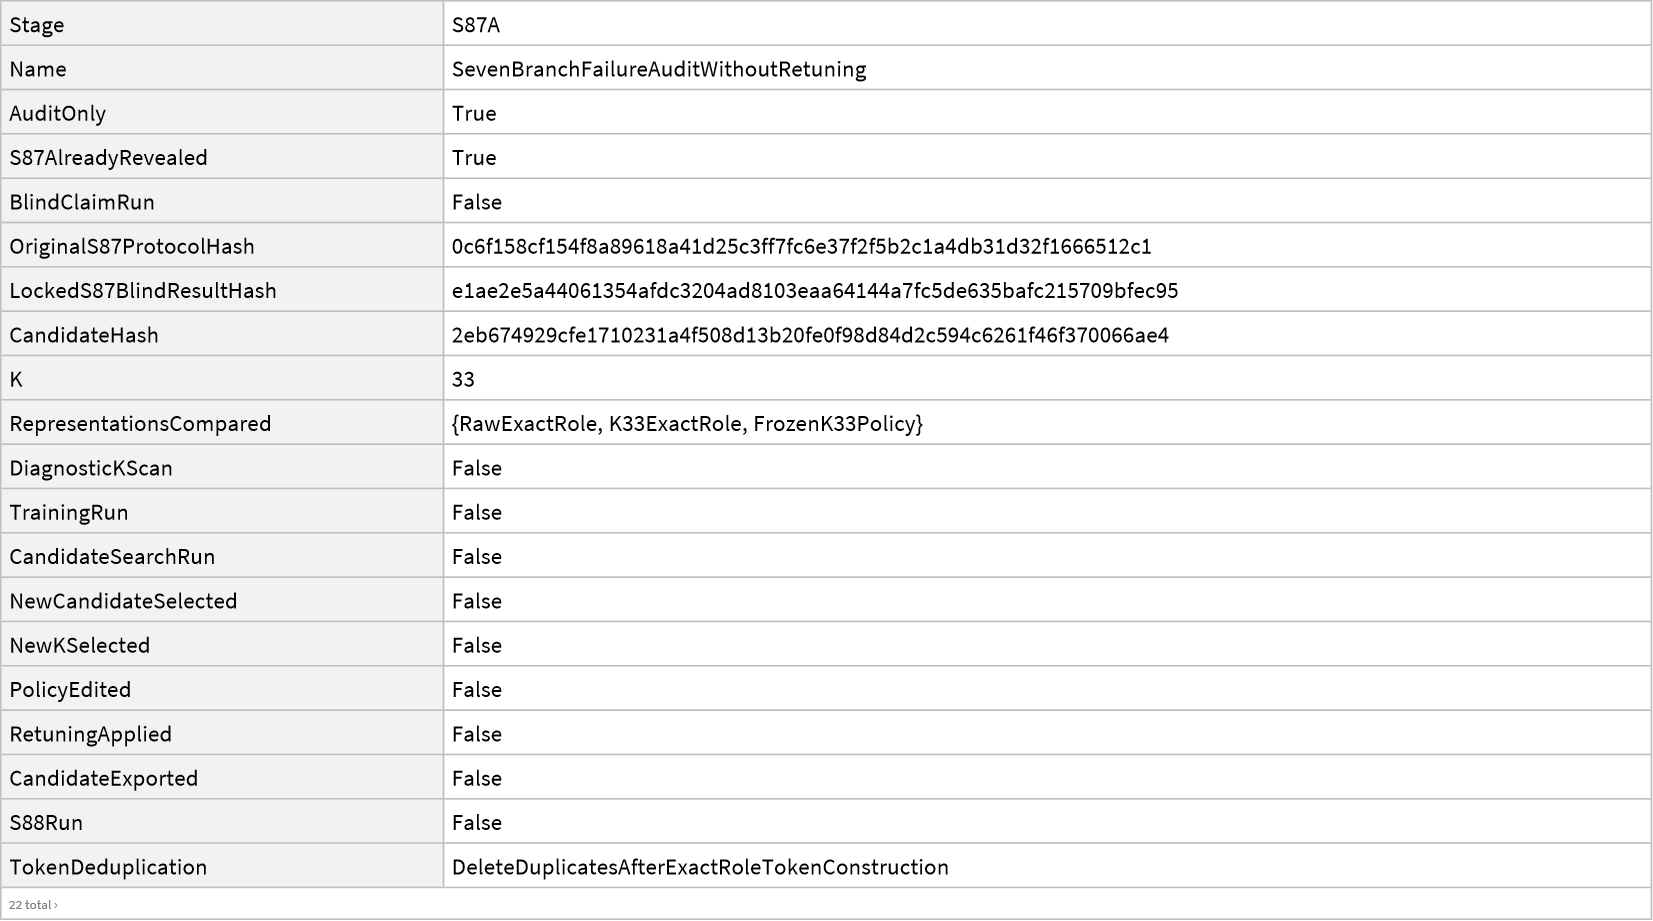

In [141]:
ClearAll[
EncodePairForK87A,
ObservationTokenForK87A,
PrepareWorld87A,
PrepareScenario87A,
TokensForKey87A,
ContinueTokensForKey87A,
StopTokensForKey87A,
SafePolicyForKey87A,
SharedTokensForKey87A,
ScoreWorldsForKey87A,
S87AAuditDefinitionBundle
];

expectedS87ProtocolHash87A=
"0c6f158cf154f8a89618a41d25c3ff7fc6e37f2f5b2c1a4db31d32f1666512c1";
lockedS87BlindResultHash87A=
"e1ae2e5a44061354afdc3204ad8103eaa64144a7fc5de635bafc215709bfec95";

encodeCache87A=<||>;

EncodePairForK87A[pair_List,k_Integer]:=Module[{key,cached,encoded,code},
key=Hash[{pair,k},"SHA256","HexString"];
cached=Lookup[encodeCache87A,key,Missing["NotCached"]];
If[!MissingQ[cached],Return[cached]];
encoded=First@EncodeRows75[
{<|
"Grammar"->"S87ARevealedAuditObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate86E["EncoderParams"],k
];
code=First[encoded["Codes"]];
AssociateTo[encodeCache87A,key->code];
code
];

ObservationTokenForK87A[observation_Association,k_Integer]:={
observation["Role"],EncodePairForK87A[observation["RawPair"],k]
};

PrepareWorld87A[
topology_String,
depth_Integer,
interventionPair_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,k33Tokens,prediction
},
topologyCase=TopologyTransform87[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions87[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole87[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"RawPair"->pair,
"Code"->EncodePair87[pair]
|>
],
packedNodes
];
rawTokens=DeleteDuplicates[({#1["Role"],#1["RawPair"]}&)/@observations];
k33Tokens=DeleteDuplicates[({#1["Role"],#1["Code"]}&)/@observations];
prediction=PredictTokens87[k33Tokens];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction87[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[observations],
"TokenCount"->Length[k33Tokens],
"DuplicateTokensRemoved"->Length[observations]-Length[k33Tokens],
"PolicyHitTokens"->Intersection[k33Tokens,frozenCandidate86E["Policy"]],
"Observations"->observations,
"RawExactTokens"->rawTokens,
"K33Tokens"->k33Tokens,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];

PrepareScenario87A[
topology_String,depth_Integer,interventionPair_List
]:=Module[
{
branchCount=7,seedCase,patch,hybridSeed,baseWorlds,hybridWorlds,
worldPairs,baseGraphHashes,hybridGraphHashes
},
seedCase=Case87[depth,1,"Continue"];
patch=MixedPathCutStopPatch87[seedCase,interventionPair];
hybridSeed=ApplyEdgePatch81[seedCase,patch];
If[SameQ[hybridSeed,$Failed],Return[$Failed]];
baseWorlds=Table[
PrepareWorld87A[
topology,depth,interventionPair,"Baseline",answer,"Continue",
SetAnswer87[seedCase,answer]
],
{answer,Range[branchCount]}
];
hybridWorlds=Table[
PrepareWorld87A[
topology,depth,interventionPair,"MixedPathCutStopIntervention",answer,
If[SameQ[answer,Last[interventionPair]],"Stop","Continue"],
SetAnswer87[hybridSeed,answer]
],
{answer,Range[branchCount]}
];
worldPairs=MapThread[
Function[{base,hybrid},
<|
"Answer"->base["Answer"],
"StopPatchedQuery"->SameQ[Last[interventionPair],base["Answer"]],
"SameQuery"->SameQ[base["Answer"],hybrid["Answer"]],
"ReferenceRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Stop"]
],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Continue"]
]
],
"PredictionRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Stop"]
],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Continue"]
]
],
"PairCorrect"->And[TrueQ[base["Correct"]],TrueQ[hybrid["Correct"]]],
"BaselineWorld"->base,
"InterventionWorld"->hybrid
|>
],
{baseWorlds,hybridWorlds}
];
baseGraphHashes=Lookup[baseWorlds,"TopologyGraphHash"];
hybridGraphHashes=Lookup[hybridWorlds,"TopologyGraphHash"];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"MixedInterventionValidity"->patch["ComponentPatchesValid"],
"MixedInterventionNoConflict"->patch["NoCrossBranchConflict"],
"MixedEditCountCorrect"->patch["ExpectedEditCount"],
"BaselineSameGraphAcrossQueries"->SameQ@@baseGraphHashes,
"InterventionSameGraphAcrossQueries"->SameQ@@hybridGraphHashes,
"MixedInterventionChangesGraph"->UnsameQ[First[baseGraphHashes],First[hybridGraphHashes]],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,"PredictionRelationCorrect"],
"AllFourteenWorldsCorrect"->And@@Join[
Lookup[baseWorlds,"Correct"],Lookup[hybridWorlds,"Correct"]
],
"WorldPairs"->worldPairs,
"BaselineWorlds"->baseWorlds,
"InterventionWorlds"->hybridWorlds
|>
];

TokensForKey87A[world_Association,key_String]:=Switch[
key,
"RawExactTokens",world["RawExactTokens"],
"K33Tokens",world["K33Tokens"],
_,$Failed
];

ContinueTokensForKey87A[worlds_List,key_String]:=Union@@Map[
TokensForKey87A[#1,key]&,
Select[worlds,SameQ[#1["Target"],"Continue"]&]
];

StopTokensForKey87A[worlds_List,key_String]:=Union@@Map[
TokensForKey87A[#1,key]&,
Select[worlds,SameQ[#1["Target"],"Stop"]&]
];

SafePolicyForKey87A[worlds_List,key_String]:=Complement[
ContinueTokensForKey87A[worlds,key],
StopTokensForKey87A[worlds,key]
];

SharedTokensForKey87A[worlds_List,key_String]:=Intersection[
ContinueTokensForKey87A[worlds,key],
StopTokensForKey87A[worlds,key]
];

ScoreWorldsForKey87A[worlds_List,key_String,policy_List]:=Count[
worlds,
world_/;SameQ[
If[AnyTrue[TokensForKey87A[world,key],MemberQ[policy,#]&],"Continue","Stop"],
world["Target"]
]
];

S87AAuditDefinitionBundle[]:={
DownValues[EncodePairForK87A],DownValues[ObservationTokenForK87A],
DownValues[PrepareWorld87A],DownValues[PrepareScenario87A],
DownValues[TokensForKey87A],DownValues[ContinueTokensForKey87A],
DownValues[StopTokensForKey87A],DownValues[SafePolicyForKey87A],
DownValues[SharedTokensForKey87A],DownValues[ScoreWorldsForKey87A]
};

auditProtocol87A=<|
"Stage"->"S87A",
"Name"->"SevenBranchFailureAuditWithoutRetuning",
"AuditOnly"->True,
"S87AlreadyRevealed"->True,
"BlindClaimRun"->False,
"OriginalS87ProtocolHash"->protocolHash87,
"LockedS87BlindResultHash"->lockedS87BlindResultHash87A,
"CandidateHash"->candidateHashLoaded87,
"K"->33,
"RepresentationsCompared"->{"RawExactRole","K33ExactRole","FrozenK33Policy"},
"DiagnosticKScan"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"NewCandidateSelected"->False,
"NewKSelected"->False,
"PolicyEdited"->False,
"RetuningApplied"->False,
"CandidateExported"->False,
"S88Run"->False,
"TokenDeduplication"->"DeleteDuplicatesAfterExactRoleTokenConstruction",
"ExpectedS87DeterministicResult"-><|
"Scenarios"->28,"WorldPairs"->196,"Worlds"->392,
"BaselineCorrect"->0,"InterventionContinueCorrect"->0,
"InterventionStopCorrect"->20,"WorldCorrect"->20,
"PairCorrect"->0,"PredictionRelationsCorrect"->0,"ScenarioPerfect"->0
|>
|>;

auditProtocolHash87A=Hash[Normal[auditProtocol87A],"SHA256","HexString"];
auditDefinitionHashBefore87A=Hash[
S87AAuditDefinitionBundle[],"SHA256","HexString"
];

Dataset[{Join[auditProtocol87A,<|"AuditProtocolHash"->auditProtocolHash87A|>]}]


Dataset[{<|Scenarios -> 28, WorldPairs -> 196, Worlds -> 392, 
 
>     MixedInterventionValidity -> 28, MixedInterventionNoConflict -> 28, 
 
>     MixedEditCountCorrect -> 28, ReferenceRelationsCorrect -> 196, 
 
>     PredictionRelationsCorrect -> 0, PairCorrect -> 0, ScenarioPerfect -> 0, 
 
>     BaselineCorrect -> 0, InterventionContinueCorrect -> 0, 
 
>     InterventionStopCorrect -> 20, WorldCorrect -> 20, 
 
>     CanonicalCaseExactlyBase -> 392, ContractionCountCorrect -> 392, 
 
>     ProtectedNodesPreserved -> 392, ReferenceActionsCorrect -> 392, 
 
>     NonEmptyTokens -> 392, TerminatedNaturally -> 392, HitSafetyCap -> 0, 
 
>     SevenBranchWorlds -> 392, TotalTraceSeconds -> 232.985|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Real], 
 
>     23], 1], <||>]
Dataset[{<|Representation -> RawExactRole, Worlds -> 392, SafePolicyScore -> 392, 
 
>     SafePolicyPerfect -> True, ContinueTokenCount -> 21, StopTokenCount -> 14, 
 
>     SharedTokenCount -> 0, SafePolicyLength -> 21, AppliedToFrozenModel -> False|>, 
 
>    <|Representation -> K33ExactRole, Worlds -> 392, SafePolicyScore -> 392, 
 
>     SafePolicyPerfect -> True, ContinueTokenCount -> 21, StopTokenCount -> 13, 
 
>     SharedTokenCount -> 0, SafePolicyLength -> 21, AppliedToFrozenModel -> False|>, 
 
>    <|Representation -> FrozenK33Policy, Worlds -> 392, SafePolicyScore -> 20, 
 
>     SafePolicyPerfect -> False, ContinueTokenCount -> Missing[NotApplicable], 
 
>     StopTokenCount -> Missing[NotApplicable], 
 
>     SharedTokenCount -> Missing[NotApplicable], SafePolicyLength -> 39, 
 
>     AppliedToFrozenModel -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Representation, Worlds, SafePolicyScore, 
 
>      SafePolicyPerfect, ContinueTokenCount, StopTokenCount, SharedTokenCount, 
 
>      SafePolicyLength, AppliedToFrozenModel}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 3], <||>]
Dataset[{<|ContinueTargets -> 364, StopTargets -> 28, PredictedContinue -> 8, 
 
>     PredictedStop -> 384, ZeroPolicyHitContinueTargets -> 364, 
 
>     ZeroPolicyHitStopTargets -> 20, PolicyHitContinueTargets -> 0, 
 
>     PolicyHitStopTargets -> 8|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>       ContinueTargets, PolicyHitContinueTargets, PolicyHitStopTargets, 
 
>       PredictedContinue, PredictedStop, StopTargets, ZeroPolicyHitContinueTargets, 
 
>       ZeroPolicyHitStopTargets]], TypeSystem`Atom[Integer], 8], 1], <||>]
Dataset[{<|Diagnosis -> FROZEN_POLICY_COVERAGE_GAP|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>     1], 1], <||>]
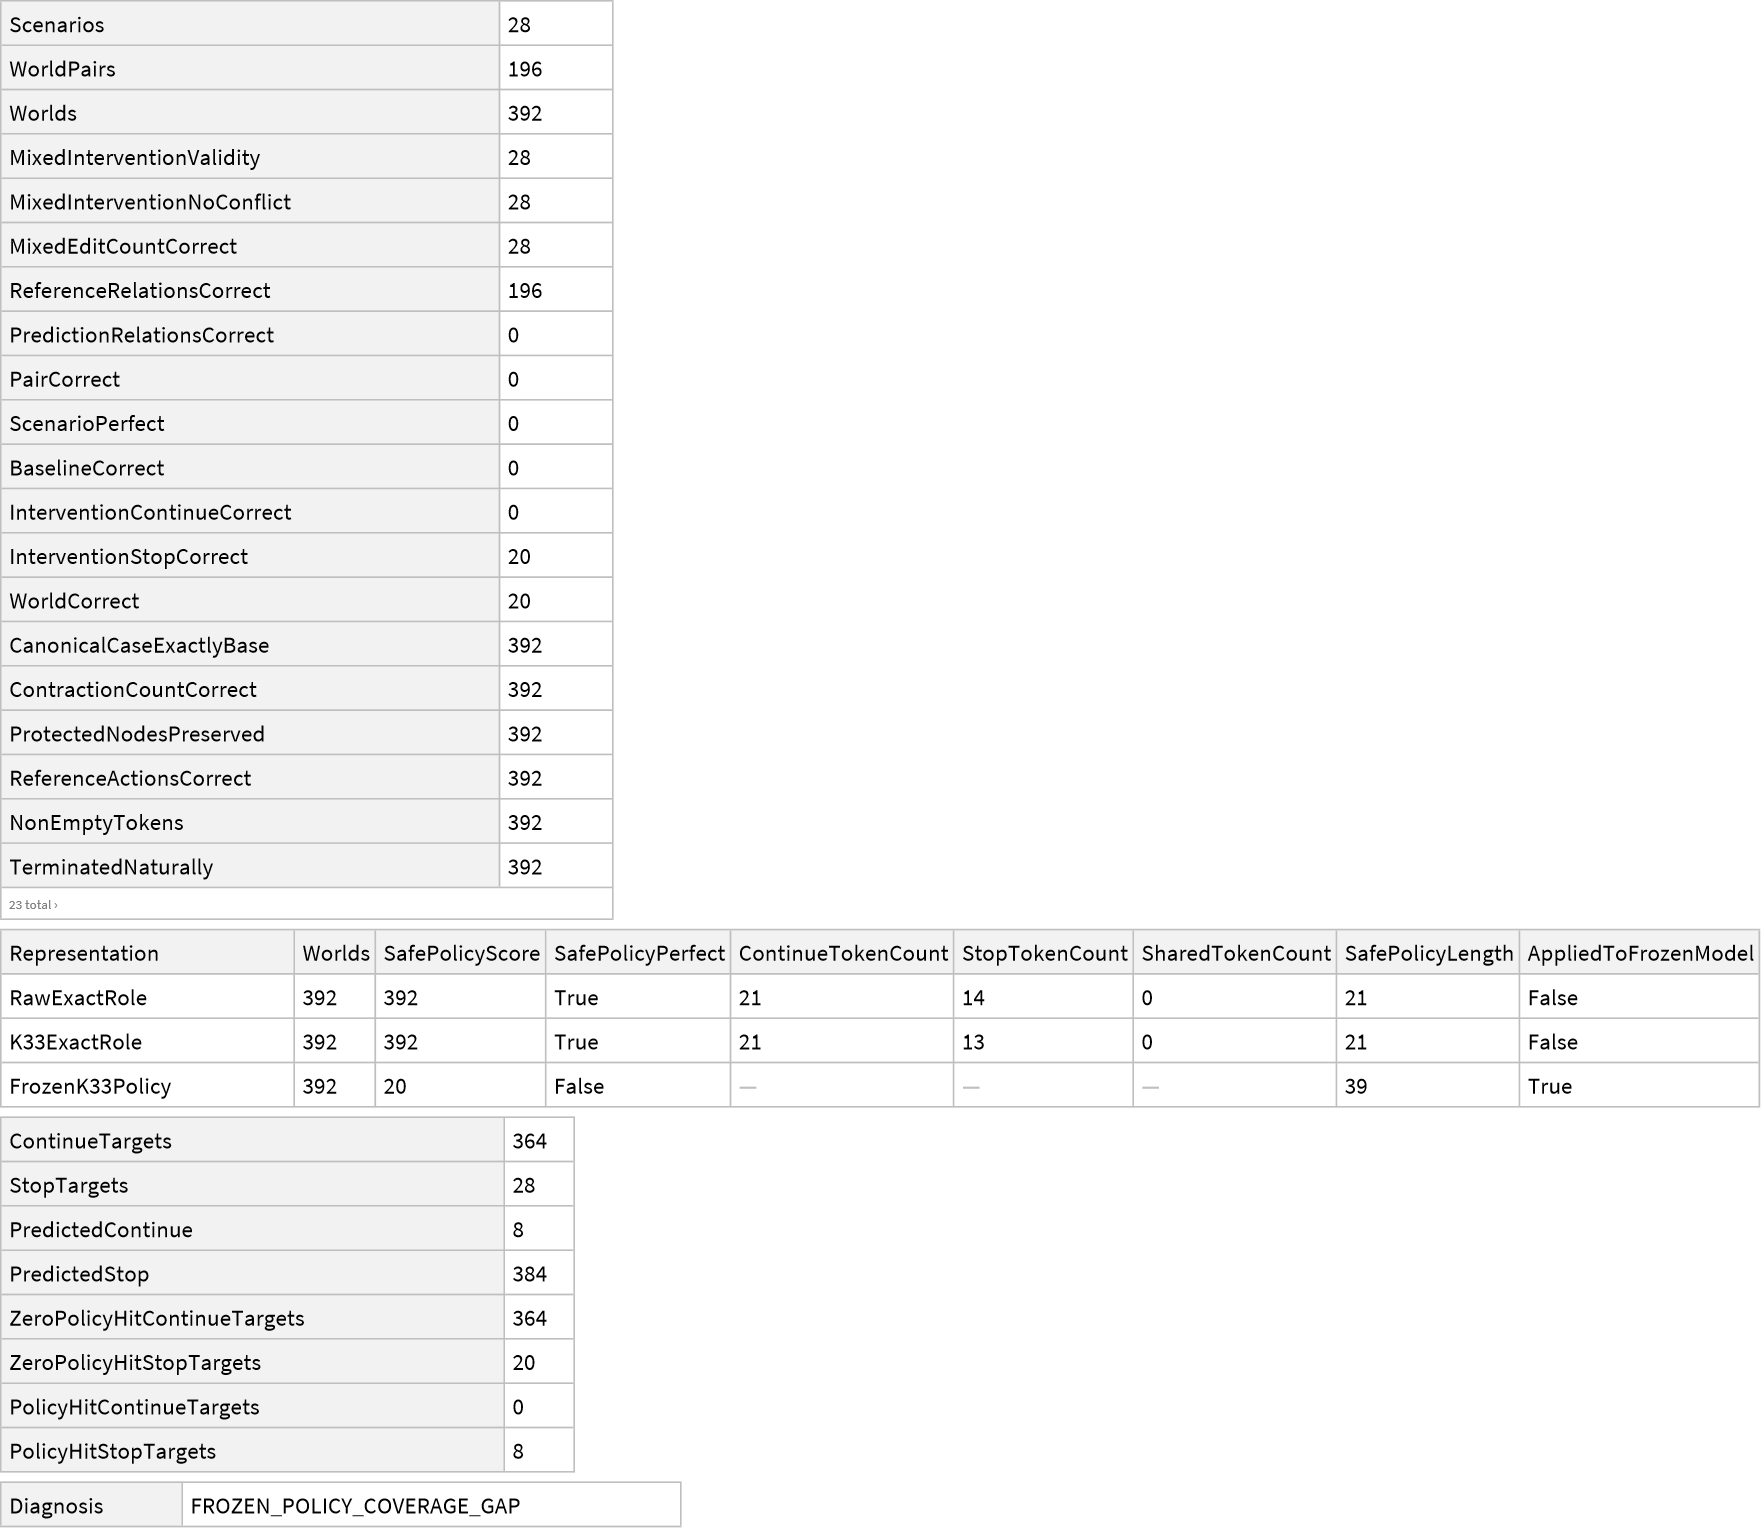

In [160]:
auditScenarios87A=Flatten[
Table[
PrepareScenario87A[topology,depth,interventionPair],
{topology,blindTopologies87},
{depth,blindDepths87},
{interventionPair,blindInterventionPairs87}
],
2
];

auditWorldPairs87A=Flatten[Lookup[auditScenarios87A,"WorldPairs"],1];
baselineWorlds87A=Flatten[Lookup[auditScenarios87A,"BaselineWorlds"],1];
interventionWorlds87A=Flatten[Lookup[auditScenarios87A,"InterventionWorlds"],1];
allWorlds87A=Join[baselineWorlds87A,interventionWorlds87A];

reproducedSummary87A=<|
"Scenarios"->Length[auditScenarios87A],
"WorldPairs"->Length[auditWorldPairs87A],
"Worlds"->Length[allWorlds87A],
"MixedInterventionValidity"->Count[
auditScenarios87A,s_/;TrueQ[s["MixedInterventionValidity"]]
],
"MixedInterventionNoConflict"->Count[
auditScenarios87A,s_/;TrueQ[s["MixedInterventionNoConflict"]]
],
"MixedEditCountCorrect"->Count[
auditScenarios87A,s_/;TrueQ[s["MixedEditCountCorrect"]]
],
"ReferenceRelationsCorrect"->Count[
auditWorldPairs87A,p_/;TrueQ[p["ReferenceRelationCorrect"]]
],
"PredictionRelationsCorrect"->Count[
auditWorldPairs87A,p_/;TrueQ[p["PredictionRelationCorrect"]]
],
"PairCorrect"->Count[auditWorldPairs87A,p_/;TrueQ[p["PairCorrect"]]],
"ScenarioPerfect"->Count[
auditScenarios87A,s_/;TrueQ[s["AllFourteenWorldsCorrect"]]
],
"BaselineCorrect"->Count[baselineWorlds87A,w_/;TrueQ[w["Correct"]]],
"InterventionContinueCorrect"->Count[
interventionWorlds87A,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"InterventionStopCorrect"->Count[
interventionWorlds87A,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"WorldCorrect"->Count[allWorlds87A,w_/;TrueQ[w["Correct"]]],
"CanonicalCaseExactlyBase"->Count[
allWorlds87A,w_/;TrueQ[w["CanonicalCaseExactlyBase"]]
],
"ContractionCountCorrect"->Count[
allWorlds87A,w_/;TrueQ[w["ContractionCountCorrect"]]
],
"ProtectedNodesPreserved"->Count[
allWorlds87A,w_/;TrueQ[w["ProtectedNodesPreserved"]]
],
"ReferenceActionsCorrect"->Count[
allWorlds87A,w_/;SameQ[w["ReferenceAction"],w["Target"]]
],
"NonEmptyTokens"->Count[allWorlds87A,w_/;w["TokenCount"]>0],
"TerminatedNaturally"->Count[
allWorlds87A,w_/;TrueQ[w["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[allWorlds87A,w_/;TrueQ[w["HitSafetyCap"]]],
"SevenBranchWorlds"->Count[allWorlds87A,w_/;SameQ[w["BranchCount"],7]],
"TotalTraceSeconds"->Total[Lookup[allWorlds87A,"TraceSeconds"]]
|>;

rawSafePolicy87A=SafePolicyForKey87A[allWorlds87A,"RawExactTokens"];
k33SafePolicy87A=SafePolicyForKey87A[allWorlds87A,"K33Tokens"];
rawSharedTokens87A=SharedTokensForKey87A[allWorlds87A,"RawExactTokens"];
k33SharedTokens87A=SharedTokensForKey87A[allWorlds87A,"K33Tokens"];

rawSafeScore87A=ScoreWorldsForKey87A[
allWorlds87A,"RawExactTokens",rawSafePolicy87A
];
k33SafeScore87A=ScoreWorldsForKey87A[
allWorlds87A,"K33Tokens",k33SafePolicy87A
];
frozenPolicyScore87A=Count[allWorlds87A,w_/;TrueQ[w["Correct"]]];

representationAudit87A={
<|
"Representation"->"RawExactRole",
"Worlds"->Length[allWorlds87A],
"SafePolicyScore"->rawSafeScore87A,
"SafePolicyPerfect"->SameQ[rawSafeScore87A,Length[allWorlds87A]],
"ContinueTokenCount"->Length@ContinueTokensForKey87A[
allWorlds87A,"RawExactTokens"
],
"StopTokenCount"->Length@StopTokensForKey87A[allWorlds87A,"RawExactTokens"],
"SharedTokenCount"->Length[rawSharedTokens87A],
"SafePolicyLength"->Length[rawSafePolicy87A],
"AppliedToFrozenModel"->False
|>,
<|
"Representation"->"K33ExactRole",
"Worlds"->Length[allWorlds87A],
"SafePolicyScore"->k33SafeScore87A,
"SafePolicyPerfect"->SameQ[k33SafeScore87A,Length[allWorlds87A]],
"ContinueTokenCount"->Length@ContinueTokensForKey87A[allWorlds87A,"K33Tokens"],
"StopTokenCount"->Length@StopTokensForKey87A[allWorlds87A,"K33Tokens"],
"SharedTokenCount"->Length[k33SharedTokens87A],
"SafePolicyLength"->Length[k33SafePolicy87A],
"AppliedToFrozenModel"->False
|>,
<|
"Representation"->"FrozenK33Policy",
"Worlds"->Length[allWorlds87A],
"SafePolicyScore"->frozenPolicyScore87A,
"SafePolicyPerfect"->SameQ[frozenPolicyScore87A,Length[allWorlds87A]],
"ContinueTokenCount"->Missing["NotApplicable"],
"StopTokenCount"->Missing["NotApplicable"],
"SharedTokenCount"->Missing["NotApplicable"],
"SafePolicyLength"->Length[frozenCandidate86E["Policy"]],
"AppliedToFrozenModel"->True
|>
};

predictionAudit87A=<|
"ContinueTargets"->Count[allWorlds87A,w_/;SameQ[w["Target"],"Continue"]],
"StopTargets"->Count[allWorlds87A,w_/;SameQ[w["Target"],"Stop"]],
"PredictedContinue"->Count[
allWorlds87A,w_/;SameQ[w["Prediction"],"Continue"]
],
"PredictedStop"->Count[allWorlds87A,w_/;SameQ[w["Prediction"],"Stop"]],
"ZeroPolicyHitContinueTargets"->Count[
allWorlds87A,w_/;SameQ[w["Target"],"Continue"]&&Length[w["PolicyHitTokens"]]===0
],
"ZeroPolicyHitStopTargets"->Count[
allWorlds87A,w_/;SameQ[w["Target"],"Stop"]&&Length[w["PolicyHitTokens"]]===0
],
"PolicyHitContinueTargets"->Count[
allWorlds87A,w_/;SameQ[w["Target"],"Continue"]&&Length[w["PolicyHitTokens"]]>0
],
"PolicyHitStopTargets"->Count[
allWorlds87A,w_/;SameQ[w["Target"],"Stop"]&&Length[w["PolicyHitTokens"]]>0
]
|>;

diagnosis87A=Which[
rawSafeScore87A<Length[allWorlds87A],
"RAW_EXACT_ROLE_NOT_SEPARABLE",
k33SafeScore87A<Length[allWorlds87A]&&
frozenPolicyScore87A<k33SafeScore87A,
"K33_COLLISION_AND_FROZEN_POLICY_COVERAGE_GAP",
k33SafeScore87A<Length[allWorlds87A],
"K33_MODULO_COLLISION",
frozenPolicyScore87A<Length[allWorlds87A],
"FROZEN_POLICY_COVERAGE_GAP",
True,
"NO_REPRESENTATION_FAILURE_FOUND"
];

Column[{
Dataset[{reproducedSummary87A}],
Dataset[representationAudit87A],
Dataset[{predictionAudit87A}],
Dataset[{<|"Diagnosis"->diagnosis87A|>}]
}]


Dataset[{<|Stage -> S87A, Name -> SevenBranchFailureAuditWithoutRetuning, 
 
>     AuditOnly -> True, AuditValidityPassed -> True, 
 
>     S87DeterministicResultReproduced -> True, 
 
>     LockedS87BlindResultHash -> 
 
>      e1ae2e5a44061354afdc3204ad8103eaa64144a7fc5de635bafc215709bfec95, 
 
>     S87ProtocolHash -> 
 
>      0c6f158cf154f8a89618a41d25c3ff7fc6e37f2f5b2c1a4db31d32f1666512c1, 
 
>     AuditProtocolHash -> 
 
>      acd4c8d4c1f651e7ccf74ffbb5756626cbcdce330440f6650ee9a537f050297e, 
 
>     WorldsAudited -> 392, FrozenPolicyScore -> 20, RawExactRoleScore -> 392, 
 
>     RawExactRolePerfect -> True, K33SafePolicyScore -> 392, 
 
>     K33SafePolicyPerfect -> True, RawSharedTokenCount -> 0, K33SharedTokenCount -> 0, 
 
>     Diagnosis -> FROZEN_POLICY_COVERAGE_GAP, OriginalFrozenModelChanged -> False, 
 
>     FrozenCandidateChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionChanged -> False, 
 
>     TopologyImplementationsChanged -> False, OriginalS87DefinitionsChanged -> False, 
 
>     OriginalS87ProtocolChanged -> False, DeduplicationMechanismChanged -> False, 
 
>     CandidateFileChanged -> False, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DiagnosticKScan -> False, NewCandidateSelected -> False, NewKSelected -> False, 
 
>     PolicyEdited -> False, RetuningApplied -> False, CandidateExported -> False, 
 
>     S87LabelsUsedForDiagnosisOnly -> True, S87LabelsAppliedToFrozenModel -> False, 
 
>     BlindClaimRun -> False, MayReplaceS87BlindResult -> False, 
 
>     TotalTraceSeconds -> 232.985, Outcome -> S87A_VALID_FAILURE_DIAGNOSIS_NO_RETUNING, 
 
>     SuggestedNextStage -> S87B_DESIGN_RESEARCH_BRANCH_FROM_DIAGNOSIS|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 42], 
 
>    1], <||>]
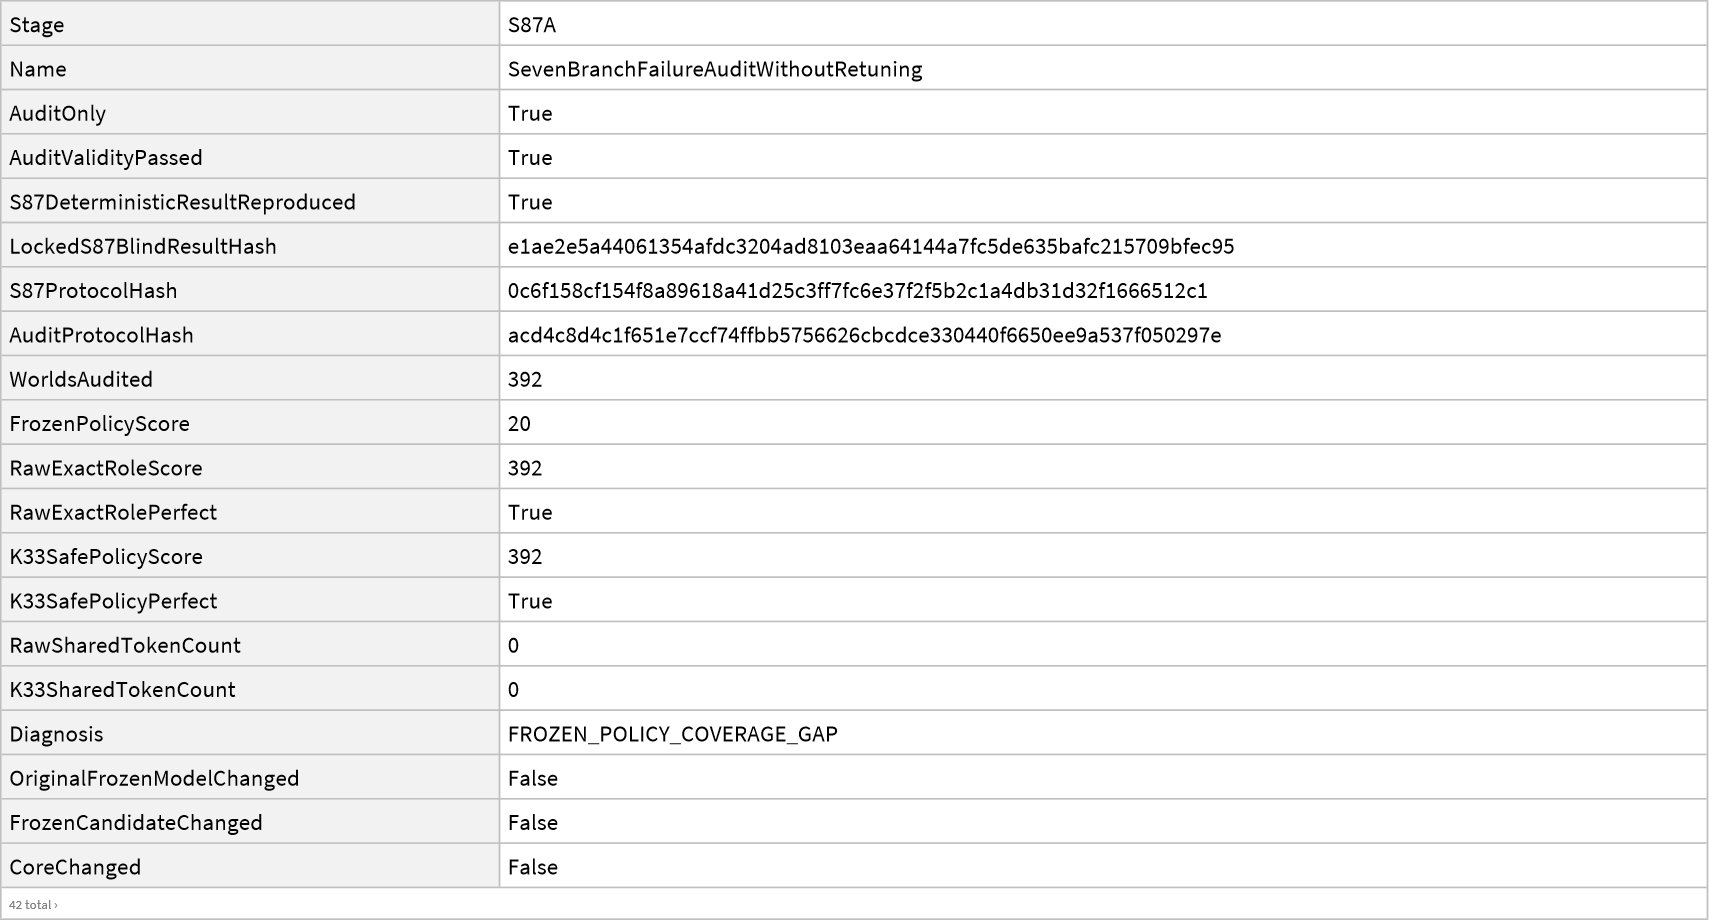

In [177]:
modelHashAfter87A=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashAfter87A=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashAfter87A=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashAfter87A=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashAfter87A=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyHashAfter87A=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
testDefinitionHashAfter87A=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];
protocolHashAfter87A=Hash[Normal[protocol87],"SHA256","HexString"];
auditProtocolHashAfter87A=Hash[
Normal[auditProtocol87A],"SHA256","HexString"
];
auditDefinitionHashAfter87A=Hash[
S87AAuditDefinitionBundle[],"SHA256","HexString"
];
k33CandidateFileHashAfter87A=FileHash[k33CandidatePath87,"SHA256"];
oldK19CandidateFileHashAfter87A=FileHash[oldK19CandidatePath87,"SHA256"];

originalFrozenModelUnchanged87A=And[
SameQ[modelHashBefore87,modelHashAfter87A],
SameQ[modelHashAfter87A,expectedFrozenModelHash79A]
];
frozenCandidateUnchanged87A=And[
SameQ[candidateHashBefore87,candidateHashAfter87A],
SameQ[candidateHashAfter87A,expectedCandidateHash87]
];
coreUnchanged87A=SameQ[coreHashBefore87,coreHashAfter87A];
canonicalizerUnchanged87A=And[
SameQ[canonicalizerHashBefore87,canonicalizerHashAfter87A],
SameQ[canonicalizerHashAfter87A,expectedCanonicalizerHash87]
];
interventionUnchanged87A=And[
SameQ[interventionHashBefore87,interventionHashAfter87A],
SameQ[interventionHashAfter87A,expectedInterventionHash87]
];
topologiesUnchanged87A=SameQ[topologyHashBefore87,topologyHashAfter87A];
originalS87DefinitionsUnchanged87A=SameQ[
testDefinitionHashBefore87,testDefinitionHashAfter87A
];
originalS87ProtocolUnchanged87A=And[
SameQ[protocolHash87,protocolHashAfter87A],
SameQ[protocolHashAfter87A,expectedS87ProtocolHash87A]
];
auditProtocolUnchanged87A=SameQ[
auditProtocolHash87A,auditProtocolHashAfter87A
];
auditDefinitionsUnchanged87A=SameQ[
auditDefinitionHashBefore87A,auditDefinitionHashAfter87A
];
deduplicationMechanismUnchanged87A=And[
TrueQ[coreUnchanged87A],
TrueQ[originalS87DefinitionsUnchanged87A],
SameQ[
protocol87["TokenDeduplication"],
"DeleteDuplicatesAfterExactRoleCodePairing"
],
SameQ[
auditProtocol87A["TokenDeduplication"],
"DeleteDuplicatesAfterExactRoleTokenConstruction"
]
];
k33CandidateFileUnchanged87A=SameQ[
k33CandidateFileHashBefore87,k33CandidateFileHashAfter87A
];
oldK19CandidateFileUnchanged87A=SameQ[
oldK19CandidateFileHashBefore87,oldK19CandidateFileHashAfter87A
];

expectedDeterministic87A=auditProtocol87A["ExpectedS87DeterministicResult"];
deterministicReproductionPassed87A=And[
SameQ[reproducedSummary87A["Scenarios"],expectedDeterministic87A["Scenarios"]],
SameQ[reproducedSummary87A["WorldPairs"],expectedDeterministic87A["WorldPairs"]],
SameQ[reproducedSummary87A["Worlds"],expectedDeterministic87A["Worlds"]],
SameQ[reproducedSummary87A["BaselineCorrect"],expectedDeterministic87A["BaselineCorrect"]],
SameQ[reproducedSummary87A["InterventionContinueCorrect"],expectedDeterministic87A["InterventionContinueCorrect"]],
SameQ[reproducedSummary87A["InterventionStopCorrect"],expectedDeterministic87A["InterventionStopCorrect"]],
SameQ[reproducedSummary87A["WorldCorrect"],expectedDeterministic87A["WorldCorrect"]],
SameQ[reproducedSummary87A["PairCorrect"],expectedDeterministic87A["PairCorrect"]],
SameQ[reproducedSummary87A["PredictionRelationsCorrect"],expectedDeterministic87A["PredictionRelationsCorrect"]],
SameQ[reproducedSummary87A["ScenarioPerfect"],expectedDeterministic87A["ScenarioPerfect"]]
];

auditValidityPassed87A=And[
TrueQ[preflightPassed87],
TrueQ[deterministicReproductionPassed87A],
SameQ[reproducedSummary87A["MixedInterventionValidity"],28],
SameQ[reproducedSummary87A["MixedInterventionNoConflict"],28],
SameQ[reproducedSummary87A["MixedEditCountCorrect"],28],
SameQ[reproducedSummary87A["ReferenceRelationsCorrect"],196],
SameQ[reproducedSummary87A["CanonicalCaseExactlyBase"],392],
SameQ[reproducedSummary87A["ContractionCountCorrect"],392],
SameQ[reproducedSummary87A["ProtectedNodesPreserved"],392],
SameQ[reproducedSummary87A["ReferenceActionsCorrect"],392],
SameQ[reproducedSummary87A["NonEmptyTokens"],392],
SameQ[reproducedSummary87A["TerminatedNaturally"],392],
SameQ[reproducedSummary87A["HitSafetyCap"],0],
SameQ[reproducedSummary87A["SevenBranchWorlds"],392],
TrueQ[originalFrozenModelUnchanged87A],
TrueQ[frozenCandidateUnchanged87A],
TrueQ[coreUnchanged87A],
TrueQ[canonicalizerUnchanged87A],
TrueQ[interventionUnchanged87A],
TrueQ[topologiesUnchanged87A],
TrueQ[originalS87DefinitionsUnchanged87A],
TrueQ[originalS87ProtocolUnchanged87A],
TrueQ[auditProtocolUnchanged87A],
TrueQ[auditDefinitionsUnchanged87A],
TrueQ[deduplicationMechanismUnchanged87A],
TrueQ[k33CandidateFileUnchanged87A],
TrueQ[oldK19CandidateFileUnchanged87A]
];

cert87A=<|
"Stage"->"S87A",
"Name"->"SevenBranchFailureAuditWithoutRetuning",
"AuditOnly"->True,
"AuditValidityPassed"->auditValidityPassed87A,
"S87DeterministicResultReproduced"->deterministicReproductionPassed87A,
"LockedS87BlindResultHash"->lockedS87BlindResultHash87A,
"S87ProtocolHash"->protocolHashAfter87A,
"AuditProtocolHash"->auditProtocolHashAfter87A,
"WorldsAudited"->Length[allWorlds87A],
"FrozenPolicyScore"->frozenPolicyScore87A,
"RawExactRoleScore"->rawSafeScore87A,
"RawExactRolePerfect"->SameQ[rawSafeScore87A,Length[allWorlds87A]],
"K33SafePolicyScore"->k33SafeScore87A,
"K33SafePolicyPerfect"->SameQ[k33SafeScore87A,Length[allWorlds87A]],
"RawSharedTokenCount"->Length[rawSharedTokens87A],
"K33SharedTokenCount"->Length[k33SharedTokens87A],
"Diagnosis"->diagnosis87A,
"OriginalFrozenModelChanged"->!TrueQ[originalFrozenModelUnchanged87A],
"FrozenCandidateChanged"->!TrueQ[frozenCandidateUnchanged87A],
"CoreChanged"->!TrueQ[coreUnchanged87A],
"CanonicalizerChanged"->!TrueQ[canonicalizerUnchanged87A],
"InterventionChanged"->!TrueQ[interventionUnchanged87A],
"TopologyImplementationsChanged"->!TrueQ[topologiesUnchanged87A],
"OriginalS87DefinitionsChanged"->!TrueQ[originalS87DefinitionsUnchanged87A],
"OriginalS87ProtocolChanged"->!TrueQ[originalS87ProtocolUnchanged87A],
"DeduplicationMechanismChanged"->!TrueQ[deduplicationMechanismUnchanged87A],
"CandidateFileChanged"->!TrueQ[k33CandidateFileUnchanged87A],
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DiagnosticKScan"->False,
"NewCandidateSelected"->False,
"NewKSelected"->False,
"PolicyEdited"->False,
"RetuningApplied"->False,
"CandidateExported"->False,
"S87LabelsUsedForDiagnosisOnly"->True,
"S87LabelsAppliedToFrozenModel"->False,
"BlindClaimRun"->False,
"MayReplaceS87BlindResult"->False,
"TotalTraceSeconds"->reproducedSummary87A["TotalTraceSeconds"],
"Outcome"->If[
TrueQ[auditValidityPassed87A],
"S87A_VALID_FAILURE_DIAGNOSIS_NO_RETUNING",
"S87A_INVALID_AUDIT"
],
"SuggestedNextStage"->If[
TrueQ[auditValidityPassed87A],
"S87B_DESIGN_RESEARCH_BRANCH_FROM_DIAGNOSIS",
"FIX_S87A_HARNESS_ONLY"
]
|>;

Dataset[{cert87A}]


## S87B - Structural policy decoder research

Run only the next two cells in the current S87A kernel. Do not restart the kernel. This revealed-data research compares exact token lookup with transparent lower-dimensional feature decoders under 11 grouped holdout folds. It does not edit or freeze the model.


Dataset[{<|Stage -> S87B, Name -> StructuralPolicyDecoderResearch, ResearchOnly -> True, 
 
>     S87AlreadyRevealed -> True, UsesS87Labels -> True, BlindTest -> False, 
 
>     InputAuditDataHash -> 
 
>      6162d1d335ddf185a4410f372e90f43c3766405068d9832c214b287bf8a377b5, 
 
>     FrozenCandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, K -> 33, 
 
>     FeatureFamilies -> 
 
>      {ExactRoleCode, RoleOnly, RoleCode1, RoleCode2, RoleDeltaMod33, RoleSumMod33, 
 
>       RoleProductMod33, RoleEquality, RoleOrder, RoleParityPair, RoleMinMaxMod11}, 
 
>     FoldAxes -> {Topology, Depth, InterventionPair}, FoldCount -> 11, 
 
>     SelectionObjective -> WorstClassAccuracyThenMeanBalancedAccuracyThenSimplicity, 
 
>     TrainingRun -> False, CoreEditApplied -> False, CandidateSearchRun -> False, 
 
>     FrozenPolicyEditApplied -> False, NewDecoderFrozen -> False, 
 
>     CandidateExported -> False, S88BlindTestRun -> False, 
 
>     ProtocolHash -> 4b4b2b85bd1ba56a296ee845037edc5f8c8e455fa461d84dcadb4fba9165bdd1|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     21], 1], <||>]
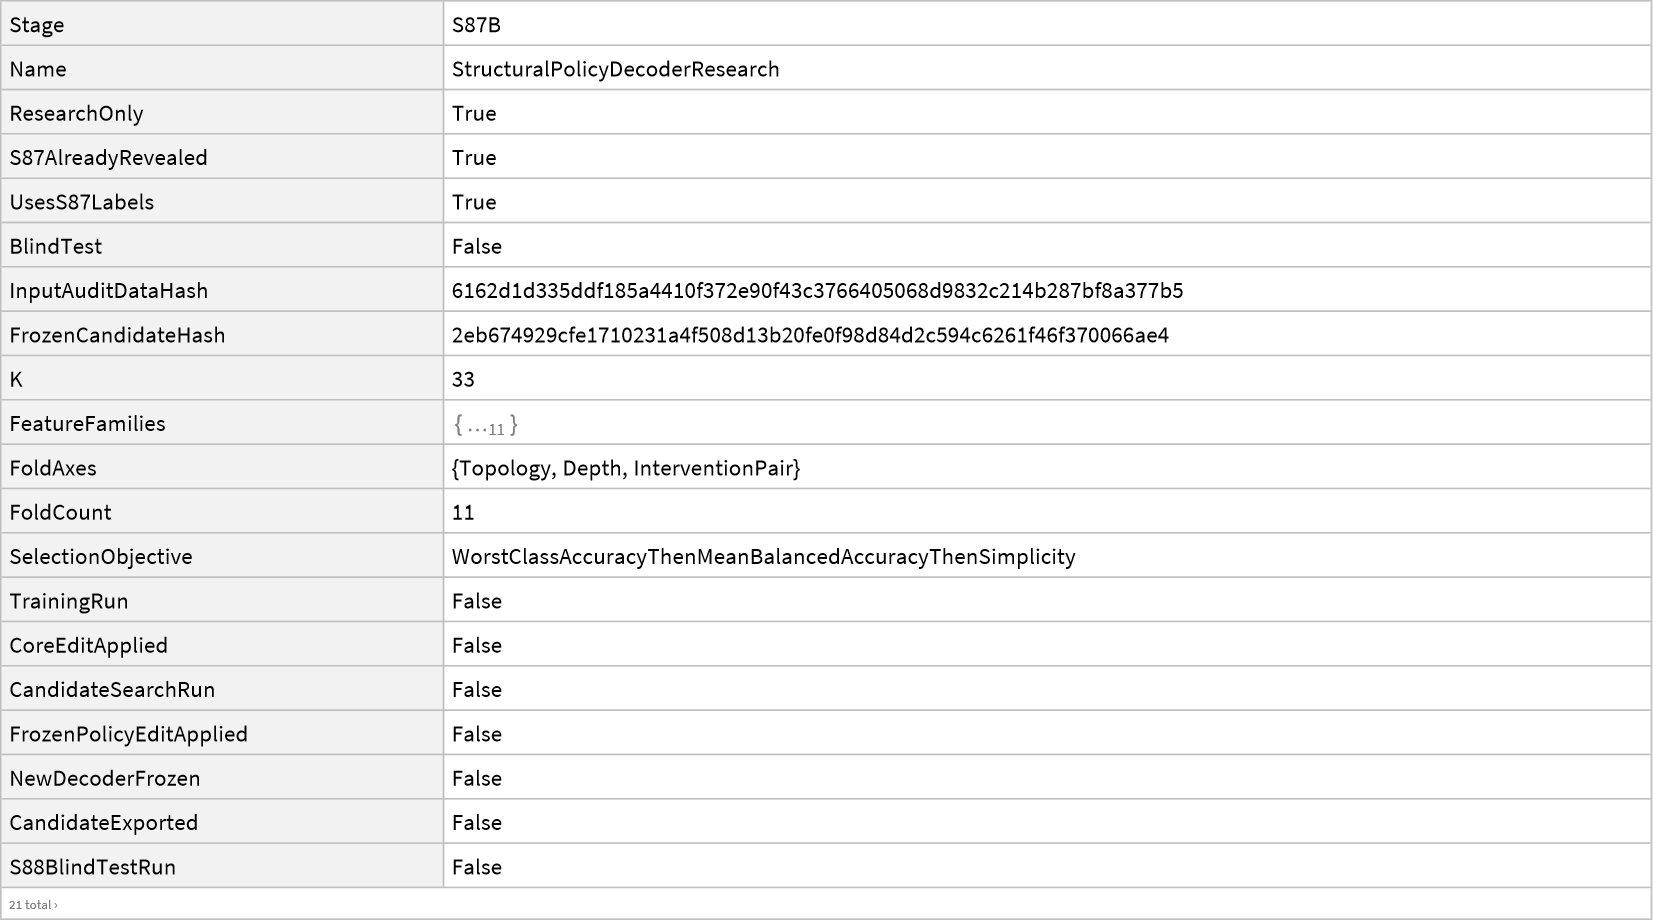

In [211]:
ClearAll[
FeatureToken87B,
WorldFeatureTokens87B,
ContinueFeatures87B,
StopFeatures87B,
SafeFeaturePolicy87B,
ScoreFeaturePolicy87B,
SplitFold87B,
EvaluateFold87B,
EvaluateFamily87B,
S87BDefinitionBundle
];

s87AStateAvailable87B=And[
ValueQ[allWorlds87A],
ValueQ[cert87A],
ValueQ[auditValidityPassed87A],
ListQ[allWorlds87A],
SameQ[Length[allWorlds87A],392],
TrueQ[auditValidityPassed87A],
SameQ[cert87A["Diagnosis"],"FROZEN_POLICY_COVERAGE_GAP"]
];

If[
!TrueQ[s87AStateAvailable87B],
Print["S87B aborted: the valid S87A runtime state is not available."];
Print["Return to this notebook's S87A cells and run them once, then run only the S87B cells."];
Abort[]
];

modelHashBefore87B=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashBefore87B=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashBefore87B=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashBefore87B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashBefore87B=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyHashBefore87B=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
originalS87DefinitionHashBefore87B=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];
k33CandidateFileHashBefore87B=FileHash[k33CandidatePath87,"SHA256"];

auditDataPayload87B=Map[
Function[world,
<|
"Topology"->world["Topology"],
"Depth"->world["Depth"],
"InterventionPair"->world["InterventionPair"],
"GraphCondition"->world["GraphCondition"],
"Answer"->world["Answer"],
"Target"->world["Target"],
"K33Tokens"->world["K33Tokens"]
|>
],
allWorlds87A
];
auditDataHashBefore87B=Hash[
Normal[auditDataPayload87B],"SHA256","HexString"
];

featureFamilies87B={
"ExactRoleCode",
"RoleOnly",
"RoleCode1",
"RoleCode2",
"RoleDeltaMod33",
"RoleSumMod33",
"RoleProductMod33",
"RoleEquality",
"RoleOrder",
"RoleParityPair",
"RoleMinMaxMod11"
};

foldSpecs87B=Join[
Map[<|"Axis"->"Topology","Heldout"->#|>&,DeleteDuplicates@Lookup[allWorlds87A,"Topology"]],
Map[<|"Axis"->"Depth","Heldout"->#|>&,DeleteDuplicates@Lookup[allWorlds87A,"Depth"]],
Map[<|"Axis"->"InterventionPair","Heldout"->#|>&,
DeleteDuplicates@Lookup[allWorlds87A,"InterventionPair"]]
];

protocol87B=<|
"Stage"->"S87B",
"Name"->"StructuralPolicyDecoderResearch",
"ResearchOnly"->True,
"S87AlreadyRevealed"->True,
"UsesS87Labels"->True,
"BlindTest"->False,
"InputAuditDataHash"->auditDataHashBefore87B,
"FrozenCandidateHash"->candidateHashBefore87B,
"K"->33,
"FeatureFamilies"->featureFamilies87B,
"FoldAxes"->{"Topology","Depth","InterventionPair"},
"FoldCount"->Length[foldSpecs87B],
"SelectionObjective"->"WorstClassAccuracyThenMeanBalancedAccuracyThenSimplicity",
"TrainingRun"->False,
"CoreEditApplied"->False,
"CandidateSearchRun"->False,
"FrozenPolicyEditApplied"->False,
"NewDecoderFrozen"->False,
"CandidateExported"->False,
"S88BlindTestRun"->False
|>;

protocolHash87B=Hash[Normal[protocol87B],"SHA256","HexString"];
Dataset[{Join[protocol87B,<|"ProtocolHash"->protocolHash87B|>]}]


Dataset[{<|Family -> ExactRoleCode, Folds -> 11, PerfectFolds -> 4, 
 
>     WorstContinueAccuracy -> 0.846154, WorstStopAccuracy -> 1., 
 
>     WorstClassAccuracy -> 0.846154, MeanBalancedAccuracy -> 0.951049, 
 
>     FullScore -> 392, FullCases -> 392, FullContinueCorrect -> 364, 
 
>     FullContinueCases -> 364, FullStopCorrect -> 28, FullStopCases -> 28, 
 
>     FullPolicyLength -> 21, SharedFeatureCount -> 0, 
 
>     NovelExactTokenContinueWorlds -> 56, NovelExactTokenContinueCorrect -> 0|>, 
 
>    <|Family -> RoleOnly, Folds -> 11, PerfectFolds -> 0, WorstContinueAccuracy -> 0., 
 
>     WorstStopAccuracy -> 1., WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.5, 
 
>     FullScore -> 28, FullCases -> 392, FullContinueCorrect -> 0, 
 
>     FullContinueCases -> 364, FullStopCorrect -> 28, FullStopCases -> 28, 
 
>     FullPolicyLength -> 0, SharedFeatureCount -> 2, 
 
>     NovelExactTokenContinueWorlds -> 56, NovelExactTokenContinueCorrect -> 0|>, 
 
>    <|Family -> RoleCode1, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0.692308, WorstStopAccuracy -> 0., 
 
>     WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.596903, FullScore -> 292, 
 
>     FullCases -> 392, FullContinueCorrect -> 264, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28, FullPolicyLength -> 5, 
 
>     SharedFeatureCount -> 10, NovelExactTokenContinueWorlds -> 56, 
 
>     NovelExactTokenContinueCorrect -> 0|>, 
 
>    <|Family -> RoleCode2, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0.461538, WorstStopAccuracy -> 0., 
 
>     WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.66034, FullScore -> 244, 
 
>     FullCases -> 392, FullContinueCorrect -> 216, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28, FullPolicyLength -> 10, 
 
>     SharedFeatureCount -> 3, NovelExactTokenContinueWorlds -> 56, 
 
>     NovelExactTokenContinueCorrect -> 16|>, 
 
>    <|Family -> RoleDeltaMod33, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0.692308, WorstStopAccuracy -> 0., 
 
>     WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.873127, FullScore -> 348, 
 
>     FullCases -> 392, FullContinueCorrect -> 320, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28, FullPolicyLength -> 15, 
 
>     SharedFeatureCount -> 1, NovelExactTokenContinueWorlds -> 56, 
 
>     NovelExactTokenContinueCorrect -> 24|>, 
 
>    <|Family -> RoleSumMod33, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0.846154, WorstStopAccuracy -> 0., 
 
>     WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.861139, FullScore -> 380, 
 
>     FullCases -> 392, FullContinueCorrect -> 352, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28, FullPolicyLength -> 16, 
 
>     SharedFeatureCount -> 3, NovelExactTokenContinueWorlds -> 56, 
 
>     NovelExactTokenContinueCorrect -> 8|>, 
 
>    <|Family -> RoleProductMod33, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0.384615, WorstStopAccuracy -> 0., 
 
>     WorstClassAccuracy -> 0., MeanBalancedAccuracy -> 0.544955, FullScore -> 188, 
 
>     FullCases -> 392, FullContinueCorrect -> 160, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28, FullPolicyLength -> 9, 
 
>     SharedFeatureCount -> 6, NovelExactTokenContinueWorlds -> 56, 
 
>     NovelExactTokenContinueCorrect -> 16|>, 
 
>    <|Family -> RoleEquality, Folds -> 11, PerfectFolds -> 0, 
 
>     WorstContinueAccuracy -> 0., WorstStopAccuracy -> 1., WorstClassAccuracy -> 0., 
 
>     MeanBalancedAccuracy -> 0.5, FullScore -> 28, FullCases -> 392, 
 
>     FullContinueCorrect -> 0, FullContinueCases -> 364, FullStopCorrect -> 28, 
 
>     FullStopCases -> 28, FullPolicyLength -> 0, SharedFeatureCount -> 2, 
 
>     NovelExactTokenContinueWorlds -> 56, NovelExactTokenContinueCorrect -> 0|>, 
 
>    <|Family -> RoleOrder, Folds -> 11, Perfect
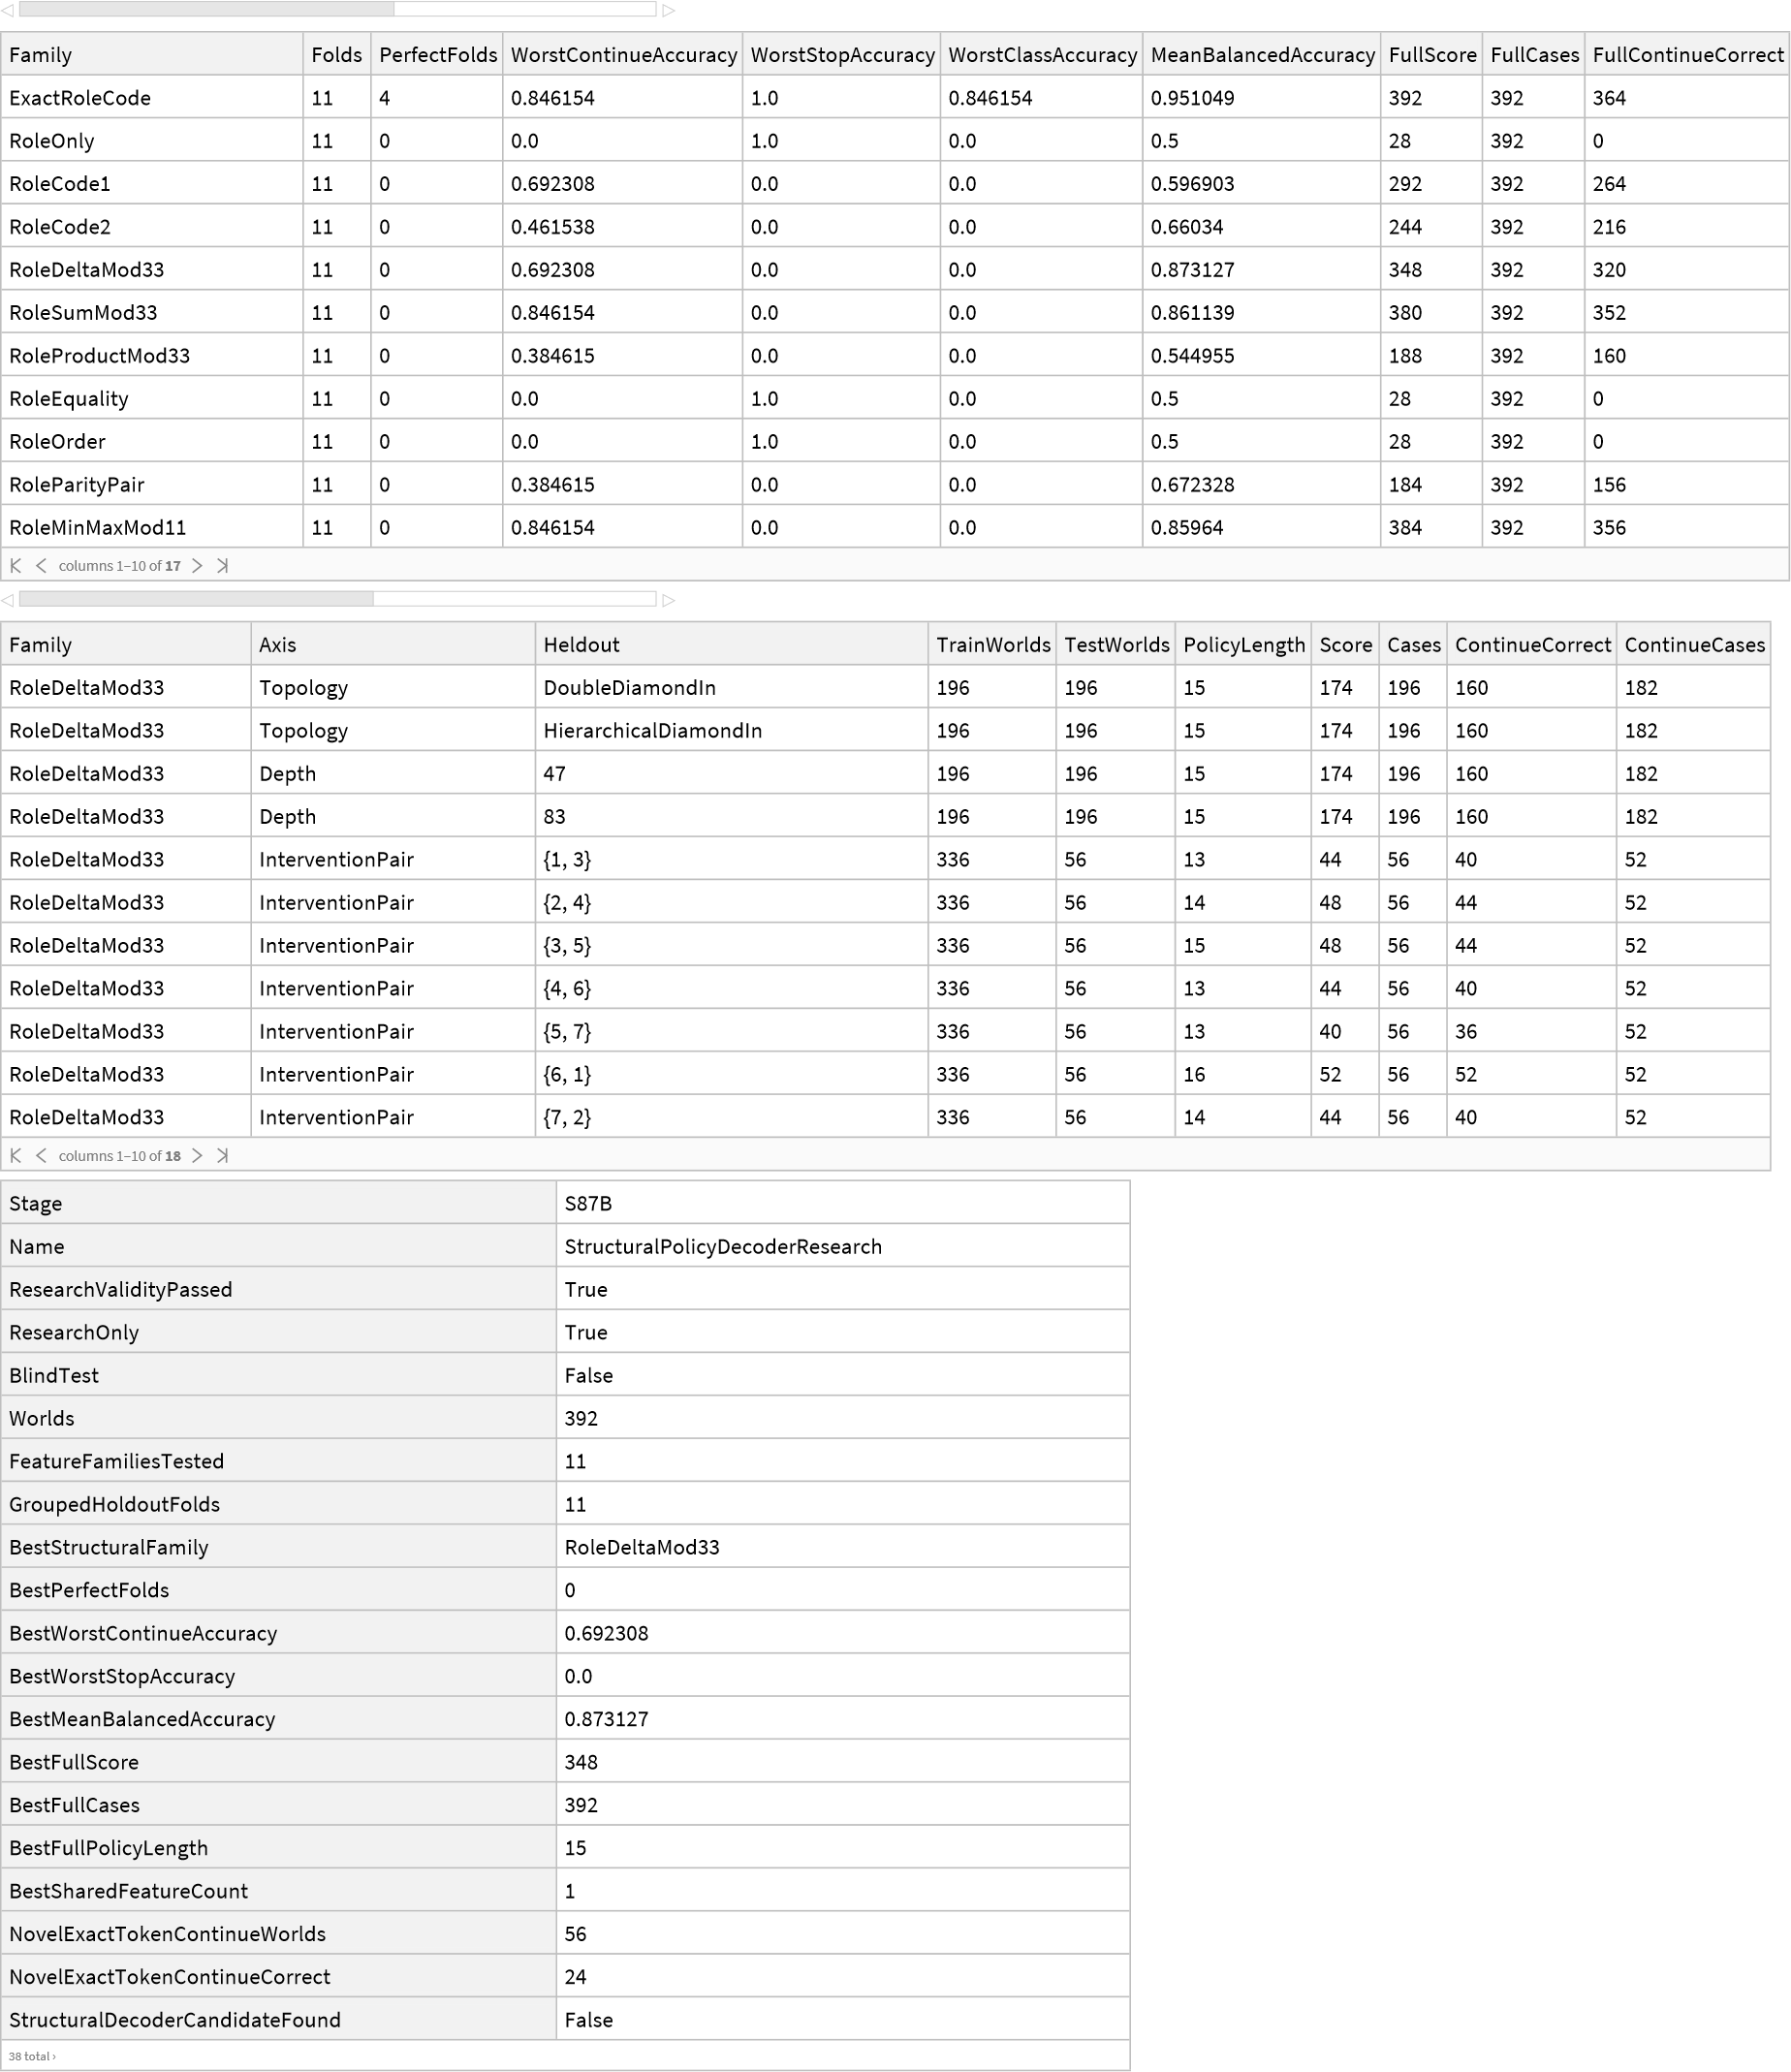

In [229]:
FeatureToken87B[token_List,family_String]:=Module[
{role,code,a,b},
role=token[[1]];
code=token[[2]];
a=code[[1]];
b=code[[2]];
Switch[
family,
"ExactRoleCode",token,
"RoleOnly",role,
"RoleCode1",{role,a},
"RoleCode2",{role,b},
"RoleDeltaMod33",{role,1+Mod[a-b,33]},
"RoleSumMod33",{role,1+Mod[a+b-2,33]},
"RoleProductMod33",{role,1+Mod[(a-1)(b-1),33]},
"RoleEquality",{role,SameQ[a,b]},
"RoleOrder",{role,Sign[a-b]},
"RoleParityPair",{role,Mod[a,2],Mod[b,2]},
"RoleMinMaxMod11",{role,Mod[Min[a,b],11],Mod[Max[a,b],11]},
_,$Failed
]
];

WorldFeatureTokens87B[world_Association,family_String]:=DeleteDuplicates[
FeatureToken87B[#,family]&/@world["K33Tokens"]
];

ContinueFeatures87B[worlds_List,family_String]:=Union@@Map[
WorldFeatureTokens87B[#,family]&,
Select[worlds,SameQ[#1["Target"],"Continue"]&]
];

StopFeatures87B[worlds_List,family_String]:=Union@@Map[
WorldFeatureTokens87B[#,family]&,
Select[worlds,SameQ[#1["Target"],"Stop"]&]
];

SafeFeaturePolicy87B[worlds_List,family_String]:=Complement[
ContinueFeatures87B[worlds,family],
StopFeatures87B[worlds,family]
];

ScoreFeaturePolicy87B[
worlds_List,family_String,policy_List
]:=Module[{predictionRows,continueRows,stopRows},
predictionRows=Map[
Function[world,
<|
"Target"->world["Target"],
"Prediction"->If[
AnyTrue[WorldFeatureTokens87B[world,family],MemberQ[policy,#]&],
"Continue","Stop"
]
|>
],
worlds
];
continueRows=Select[predictionRows,SameQ[#1["Target"],"Continue"]&];
stopRows=Select[predictionRows,SameQ[#1["Target"],"Stop"]&];
<|
"Score"->Count[predictionRows,row_/;SameQ[row["Prediction"],row["Target"]]],
"Cases"->Length[predictionRows],
"ContinueCorrect"->Count[
continueRows,row_/;SameQ[row["Prediction"],"Continue"]
],
"ContinueCases"->Length[continueRows],
"StopCorrect"->Count[stopRows,row_/;SameQ[row["Prediction"],"Stop"]],
"StopCases"->Length[stopRows]
|>
];

SplitFold87B[worlds_List,fold_Association]:=Module[{axis,value,test,train},
axis=fold["Axis"];
value=fold["Heldout"];
test=Select[worlds,SameQ[#1[axis],value]&];
train=Select[worlds,!SameQ[#1[axis],value]&];
<|"Train"->train,"Test"->test|>
];

EvaluateFold87B[
worlds_List,family_String,fold_Association
]:=Module[
{split,train,test,policy,score,exactTrainPolicy,novelContinue,novelCorrect},
split=SplitFold87B[worlds,fold];
train=split["Train"];
test=split["Test"];
policy=SafeFeaturePolicy87B[train,family];
score=ScoreFeaturePolicy87B[test,family,policy];
exactTrainPolicy=SafeFeaturePolicy87B[train,"ExactRoleCode"];
novelContinue=Select[
test,
SameQ[#1["Target"],"Continue"]&&
Intersection[#1["K33Tokens"],exactTrainPolicy]==={}&
];
novelCorrect=Count[
novelContinue,
world_/;AnyTrue[
WorldFeatureTokens87B[world,family],MemberQ[policy,#]&
]
];
Join[
<|
"Family"->family,
"Axis"->fold["Axis"],
"Heldout"->fold["Heldout"],
"TrainWorlds"->Length[train],
"TestWorlds"->Length[test],
"PolicyLength"->Length[policy]
|>,
score,
<|
"ContinueAccuracy"->N[score["ContinueCorrect"]/score["ContinueCases"]],
"StopAccuracy"->N[score["StopCorrect"]/score["StopCases"]],
"BalancedAccuracy"->N[Mean[{
score["ContinueCorrect"]/score["ContinueCases"],
score["StopCorrect"]/score["StopCases"]
}]],
"Perfect"->SameQ[score["Score"],score["Cases"]],
"NovelExactTokenContinueWorlds"->Length[novelContinue],
"NovelExactTokenContinueCorrect"->novelCorrect
|>
]
];

EvaluateFamily87B[worlds_List,family_String]:=Module[
{foldRows,fullPolicy,fullScore,perfectFolds,worstContinue,worstStop,meanBalanced},
foldRows=EvaluateFold87B[worlds,family,#]&/@foldSpecs87B;
fullPolicy=SafeFeaturePolicy87B[worlds,family];
fullScore=ScoreFeaturePolicy87B[worlds,family,fullPolicy];
perfectFolds=Count[foldRows,row_/;TrueQ[row["Perfect"]]];
worstContinue=Min[Lookup[foldRows,"ContinueAccuracy"]];
worstStop=Min[Lookup[foldRows,"StopAccuracy"]];
meanBalanced=Mean[Lookup[foldRows,"BalancedAccuracy"]];
<|
"Family"->family,
"Folds"->Length[foldRows],
"PerfectFolds"->perfectFolds,
"WorstContinueAccuracy"->worstContinue,
"WorstStopAccuracy"->worstStop,
"WorstClassAccuracy"->Min[worstContinue,worstStop],
"MeanBalancedAccuracy"->meanBalanced,
"FullScore"->fullScore["Score"],
"FullCases"->fullScore["Cases"],
"FullContinueCorrect"->fullScore["ContinueCorrect"],
"FullContinueCases"->fullScore["ContinueCases"],
"FullStopCorrect"->fullScore["StopCorrect"],
"FullStopCases"->fullScore["StopCases"],
"FullPolicyLength"->Length[fullPolicy],
"SharedFeatureCount"->Length@Intersection[
ContinueFeatures87B[worlds,family],StopFeatures87B[worlds,family]
],
"NovelExactTokenContinueWorlds"->Total@Lookup[
foldRows,"NovelExactTokenContinueWorlds"
],
"NovelExactTokenContinueCorrect"->Total@Lookup[
foldRows,"NovelExactTokenContinueCorrect"
],
"FoldRows"->foldRows,
"FullPolicy"->fullPolicy
|>
];

S87BDefinitionBundle[]:={
DownValues[FeatureToken87B],DownValues[WorldFeatureTokens87B],
DownValues[ContinueFeatures87B],DownValues[StopFeatures87B],
DownValues[SafeFeaturePolicy87B],DownValues[ScoreFeaturePolicy87B],
DownValues[SplitFold87B],DownValues[EvaluateFold87B],
DownValues[EvaluateFamily87B]
};

definitionHashBeforeEvaluation87B=Hash[
S87BDefinitionBundle[],"SHA256","HexString"
];

familyResults87B=EvaluateFamily87B[allWorlds87A,#]&/@featureFamilies87B;
structuralResults87B=Select[
familyResults87B,!SameQ[#1["Family"],"ExactRoleCode"]&
];
rankedStructuralResults87B=SortBy[
structuralResults87B,
{
-#1["PerfectFolds"],
-#1["WorstClassAccuracy"],
-#1["MeanBalancedAccuracy"],
-#1["FullScore"],
#1["FullPolicyLength"],
#1["Family"]
}&
];
bestStructuralResult87B=First[rankedStructuralResults87B];
bestStructuralFamily87B=bestStructuralResult87B["Family"];
bestStructuralFoldRows87B=bestStructuralResult87B["FoldRows"];

structuralCandidateFound87B=And[
SameQ[bestStructuralResult87B["PerfectFolds"],Length[foldSpecs87B]],
SameQ[bestStructuralResult87B["FullScore"],Length[allWorlds87A]],
SameQ[bestStructuralResult87B["WorstContinueAccuracy"],1.],
SameQ[bestStructuralResult87B["WorstStopAccuracy"],1.]
];

modelHashAfter87B=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashAfter87B=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashAfter87B=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashAfter87B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashAfter87B=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyHashAfter87B=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
originalS87DefinitionHashAfter87B=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];
definitionHashAfterEvaluation87B=Hash[
S87BDefinitionBundle[],"SHA256","HexString"
];
protocolHashAfter87B=Hash[Normal[protocol87B],"SHA256","HexString"];
auditDataHashAfter87B=Hash[Normal[auditDataPayload87B],"SHA256","HexString"];
k33CandidateFileHashAfter87B=FileHash[k33CandidatePath87,"SHA256"];

coreUnchanged87B=SameQ[coreHashBefore87B,coreHashAfter87B];
deduplicationMechanismUnchanged87B=And[
TrueQ[coreUnchanged87B],
SameQ[
protocol87["TokenDeduplication"],
"DeleteDuplicatesAfterExactRoleCodePairing"
]
];

researchValidityPassed87B=And[
SameQ[Length[foldSpecs87B],11],
SameQ[Length[familyResults87B],Length[featureFamilies87B]],
SameQ[modelHashBefore87B,modelHashAfter87B],
SameQ[candidateHashBefore87B,candidateHashAfter87B],
TrueQ[coreUnchanged87B],
SameQ[canonicalizerHashBefore87B,canonicalizerHashAfter87B],
SameQ[interventionHashBefore87B,interventionHashAfter87B],
SameQ[topologyHashBefore87B,topologyHashAfter87B],
SameQ[
originalS87DefinitionHashBefore87B,originalS87DefinitionHashAfter87B
],
SameQ[definitionHashBeforeEvaluation87B,definitionHashAfterEvaluation87B],
SameQ[protocolHash87B,protocolHashAfter87B],
SameQ[auditDataHashBefore87B,auditDataHashAfter87B],
SameQ[k33CandidateFileHashBefore87B,k33CandidateFileHashAfter87B],
TrueQ[deduplicationMechanismUnchanged87B]
];

cert87B=<|
"Stage"->"S87B",
"Name"->"StructuralPolicyDecoderResearch",
"ResearchValidityPassed"->researchValidityPassed87B,
"ResearchOnly"->True,
"BlindTest"->False,
"Worlds"->Length[allWorlds87A],
"FeatureFamiliesTested"->Length[featureFamilies87B],
"GroupedHoldoutFolds"->Length[foldSpecs87B],
"BestStructuralFamily"->bestStructuralFamily87B,
"BestPerfectFolds"->bestStructuralResult87B["PerfectFolds"],
"BestWorstContinueAccuracy"->bestStructuralResult87B["WorstContinueAccuracy"],
"BestWorstStopAccuracy"->bestStructuralResult87B["WorstStopAccuracy"],
"BestMeanBalancedAccuracy"->bestStructuralResult87B["MeanBalancedAccuracy"],
"BestFullScore"->bestStructuralResult87B["FullScore"],
"BestFullCases"->bestStructuralResult87B["FullCases"],
"BestFullPolicyLength"->bestStructuralResult87B["FullPolicyLength"],
"BestSharedFeatureCount"->bestStructuralResult87B["SharedFeatureCount"],
"NovelExactTokenContinueWorlds"->
bestStructuralResult87B["NovelExactTokenContinueWorlds"],
"NovelExactTokenContinueCorrect"->
bestStructuralResult87B["NovelExactTokenContinueCorrect"],
"StructuralDecoderCandidateFound"->structuralCandidateFound87B,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore87B,modelHashAfter87B],
"FrozenCandidateChanged"->!SameQ[candidateHashBefore87B,candidateHashAfter87B],
"CoreChanged"->!TrueQ[coreUnchanged87B],
"CanonicalizerChanged"->!SameQ[
canonicalizerHashBefore87B,canonicalizerHashAfter87B
],
"InterventionChanged"->!SameQ[
interventionHashBefore87B,interventionHashAfter87B
],
"TopologyImplementationsChanged"->!SameQ[
topologyHashBefore87B,topologyHashAfter87B
],
"DeduplicationMechanismChanged"->!TrueQ[
deduplicationMechanismUnchanged87B
],
"CandidateFileChanged"->!SameQ[
k33CandidateFileHashBefore87B,k33CandidateFileHashAfter87B
],
"UsesRevealedS87Labels"->True,
"S87LabelsAppliedToFrozenModel"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"FrozenPolicyEditApplied"->False,
"NewDecoderFrozen"->False,
"CandidateExported"->False,
"MayClaimNewBlindGeneralization"->False,
"Outcome"->Which[
!TrueQ[researchValidityPassed87B],
"S87B_INVALID_RESEARCH_AUDIT",
TrueQ[structuralCandidateFound87B],
"S87B_STRUCTURAL_DECODER_CANDIDATE_FOUND_NOT_FROZEN",
True,
"S87B_NO_PERFECT_STRUCTURAL_DECODER_CANDIDATE"
],
"SuggestedNextStage"->If[
TrueQ[structuralCandidateFound87B],
"S87C_FREEZE_DECODER_THEN_DESIGN_S88_BLIND",
"S87C_EXPAND_TRANSPARENT_DECODER_FAMILY_WITHOUT_BLIND_DATA"
]
|>;

Column[{
Dataset[Map[KeyDrop[#,{"FoldRows","FullPolicy"}]&,familyResults87B]],
Dataset[bestStructuralFoldRows87B],
Dataset[{cert87B}]
}]


## S87C - World multiset decoder research

Run only the next two cells in the current kernel. This stage uses local observation multisets and a balanced deterministic decision tree under the same 11 grouped holdouts. Topology, depth, intervention identifiers, answer, graph condition, and target are never decoder features. No model component is edited or frozen.


Dataset[{<|Stage -> S87C, Name -> WorldMultisetDecoderResearch, ResearchOnly -> True, 
 
>     S87AlreadyRevealed -> True, UsesS87Labels -> True, BlindTest -> False, 
 
>     InputDataHash -> 6162d1d335ddf185a4410f372e90f43c3766405068d9832c214b287bf8a377b5, 
 
>     FrozenCandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, K -> 33, 
 
>     ObservationInputs -> {Role, QueryBranchRelated, Code}, 
 
>     ForbiddenFeatureInputs -> 
 
>      {Topology, Depth, InterventionPair, Answer, GraphCondition, Target}, 
 
>     ForbiddenInputsUsedForFoldSplittingOnly -> True, 
 
>     FeatureFamilies -> 
 
>      {QueriedGlobalMoments, QueriedRoleMoments, AllRoleMoments, QueriedRoleHistograms, 
 
>       QueriedRoleMomentsHistograms, AllRoleMomentsQueriedHistograms, 
 
>       QueriedRoleMomentsPairwise}, Classifier -> BalancedDeterministicDecisionTree, 
 
>     FoldAxes -> {Topology, Depth, InterventionPair}, FoldCount -> 11, 
 
>     CandidateCriterion -> PerfectBothClassesOnAllElevenGroupedHoldouts, 
 
>     DecoderResearchTrainingRun -> True, FrozenModelTrainingRun -> False, 
 
>     DecoderFamilySearchRun -> True, FrozenCandidateSearchRun -> False, 
 
>     CoreEditApplied -> False, FrozenPolicyEditApplied -> False, 
 
>     NewDecoderFrozen -> False, CandidateExported -> False, S88BlindTestRun -> False, 
 
>     ProtocolHash -> f6494778c0d2bc7757edf9bcbc304942c57d44638706249c675a2a41e480d3cd|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     27], 1], <||>]
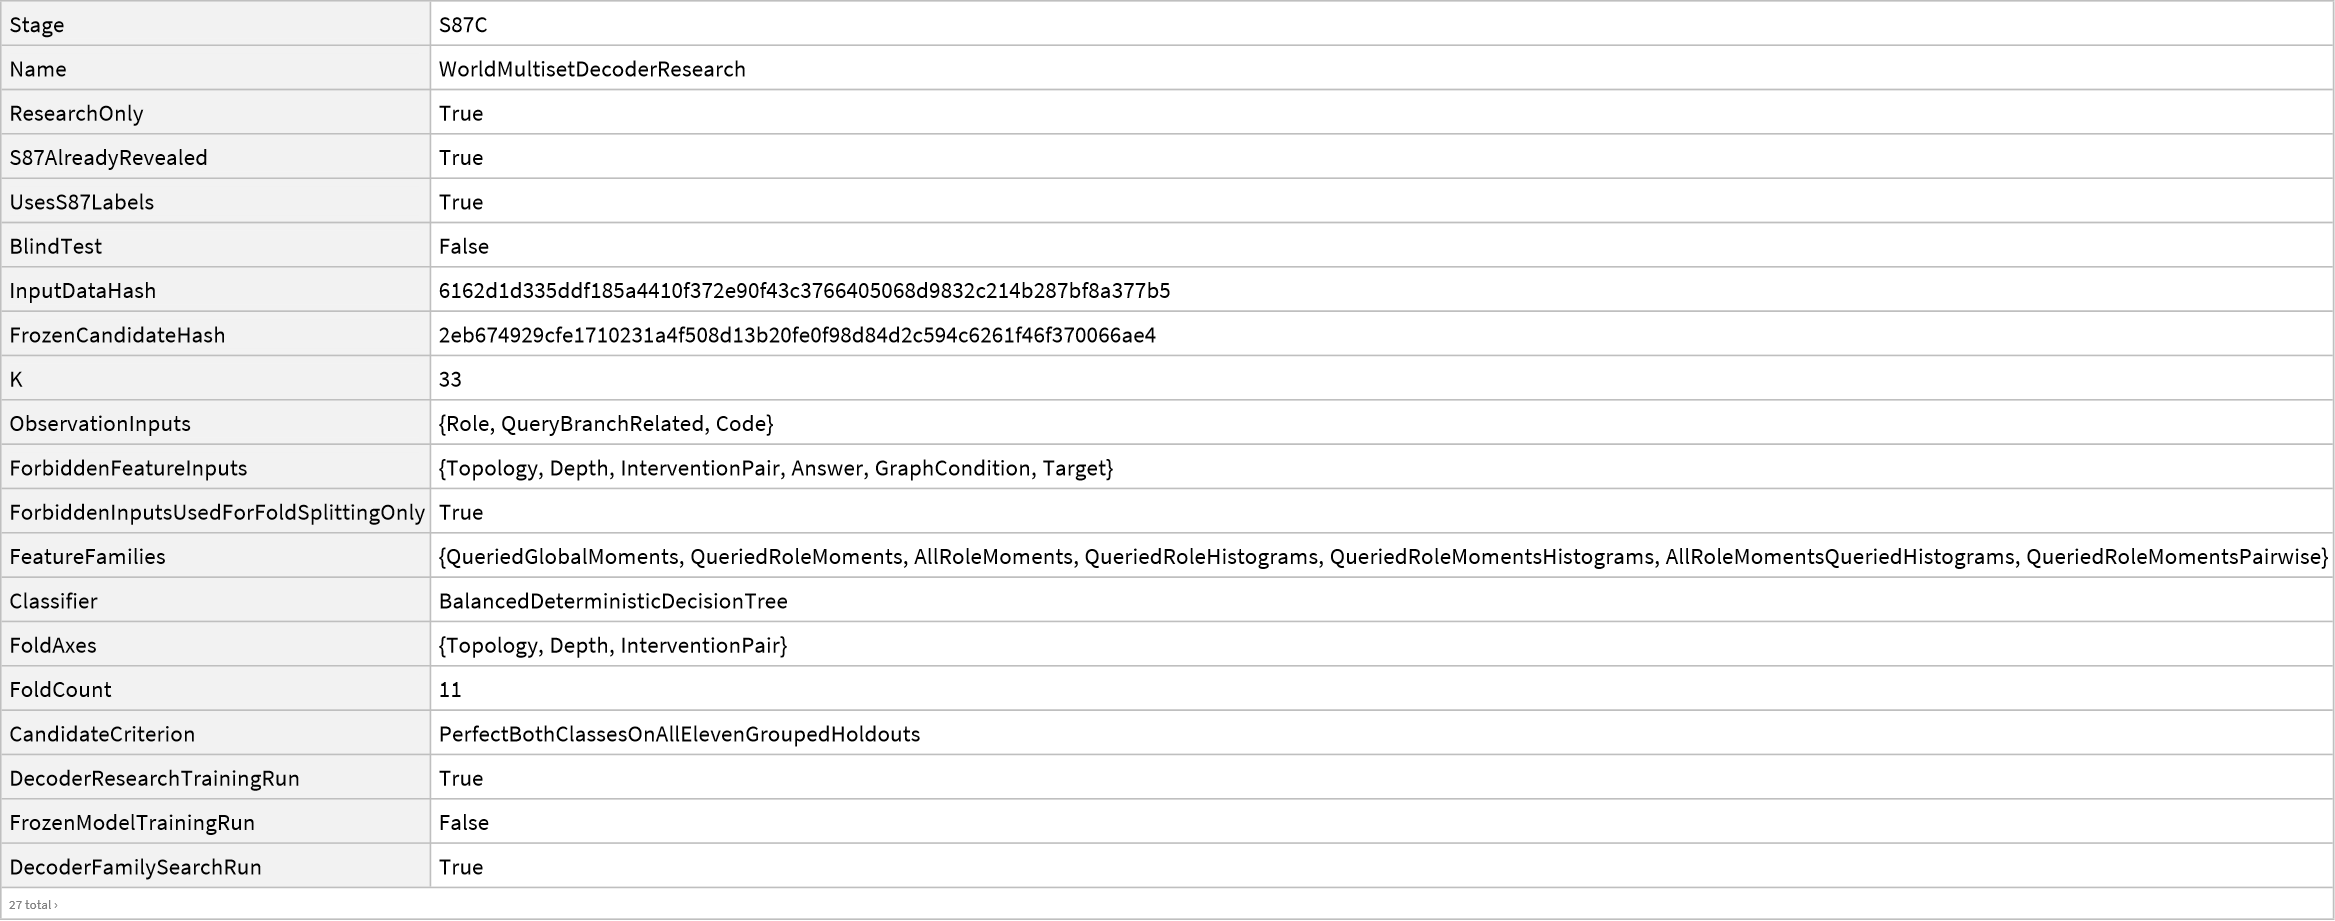

In [267]:
ClearAll[
CodeStats87C,
CodeHistogram87C,
PairwiseStats87C,
SelectRoleObservations87C,
WorldVector87C,
BuildFeatureRows87C,
SplitFeatureRows87C,
BalancedTrainingRules87C,
ScorePredictions87C,
EvaluateDecoderFold87C,
EvaluateDecoderFamily87C,
S87CDefinitionBundle
];

s87BStateAvailable87C=And[
ValueQ[allWorlds87A],
ValueQ[cert87A],
ValueQ[cert87B],
ListQ[allWorlds87A],
SameQ[Length[allWorlds87A],392],
TrueQ[cert87A["AuditValidityPassed"]],
TrueQ[cert87B["ResearchValidityPassed"]],
SameQ[cert87B["Outcome"],"S87B_NO_PERFECT_STRUCTURAL_DECODER_CANDIDATE"]
];

If[
!TrueQ[s87BStateAvailable87C],
Print["S87C aborted: the valid S87A/S87B runtime state is not available."];
Print["Run the existing S87A and S87B cells once, then run only S87C."];
Abort[]
];

modelHashBefore87C=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashBefore87C=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashBefore87C=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashBefore87C=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashBefore87C=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyHashBefore87C=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
originalS87DefinitionHashBefore87C=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];
k33CandidateFileHashBefore87C=FileHash[k33CandidatePath87,"SHA256"];

inputDataHashBefore87C=Hash[Normal[auditDataPayload87B],"SHA256","HexString"];

allRoles87C={
"QueriedDecision",
"QueriedMediatorSource",
"QueriedCorrectDestination",
"QueriedWrongDestination",
"QueriedDummyDestination",
"OtherDecision",
"OtherAnswerDestination",
"OtherReject"
};
queriedRoles87C=Take[allRoles87C,5];

featureFamilies87C={
"QueriedGlobalMoments",
"QueriedRoleMoments",
"AllRoleMoments",
"QueriedRoleHistograms",
"QueriedRoleMomentsHistograms",
"AllRoleMomentsQueriedHistograms",
"QueriedRoleMomentsPairwise"
};

protocol87C=<|
"Stage"->"S87C",
"Name"->"WorldMultisetDecoderResearch",
"ResearchOnly"->True,
"S87AlreadyRevealed"->True,
"UsesS87Labels"->True,
"BlindTest"->False,
"InputDataHash"->inputDataHashBefore87C,
"FrozenCandidateHash"->candidateHashBefore87C,
"K"->33,
"ObservationInputs"->{"Role","QueryBranchRelated","Code"},
"ForbiddenFeatureInputs"->{
"Topology","Depth","InterventionPair","Answer","GraphCondition","Target"
},
"ForbiddenInputsUsedForFoldSplittingOnly"->True,
"FeatureFamilies"->featureFamilies87C,
"Classifier"->"BalancedDeterministicDecisionTree",
"FoldAxes"->{"Topology","Depth","InterventionPair"},
"FoldCount"->Length[foldSpecs87B],
"CandidateCriterion"->"PerfectBothClassesOnAllElevenGroupedHoldouts",
"DecoderResearchTrainingRun"->True,
"FrozenModelTrainingRun"->False,
"DecoderFamilySearchRun"->True,
"FrozenCandidateSearchRun"->False,
"CoreEditApplied"->False,
"FrozenPolicyEditApplied"->False,
"NewDecoderFrozen"->False,
"CandidateExported"->False,
"S88BlindTestRun"->False
|>;

protocolHash87C=Hash[Normal[protocol87C],"SHA256","HexString"];
Dataset[{Join[protocol87C,<|"ProtocolHash"->protocolHash87C|>]}]


Dataset[{<|Family -> QueriedGlobalMoments, FeatureDimension -> 27, Folds -> 11, 
 
>     ValidFolds -> 11, PerfectFolds -> 11, WorstContinueAccuracy -> 1., 
 
>     WorstStopAccuracy -> 1., WorstClassAccuracy -> 1., MeanBalancedAccuracy -> 1., 
 
>     FullScore -> 392, FullCases -> 392, FullContinueCorrect -> 364, 
 
>     FullContinueCases -> 364, FullStopCorrect -> 28, FullStopCases -> 28|>, 
 
>    <|Family -> QueriedRoleMoments, FeatureDimension -> 85, Folds -> 11, 
 
>     ValidFolds -> 11, PerfectFolds -> 11, WorstContinueAccuracy -> 1., 
 
>     WorstStopAccuracy -> 1., WorstClassAccuracy -> 1., MeanBalancedAccuracy -> 1., 
 
>     FullScore -> 392, FullCases -> 392, FullContinueCorrect -> 364, 
 
>     FullContinueCases -> 364, FullStopCorrect -> 28, FullStopCases -> 28|>, 
 
>    <|Family -> AllRoleMoments, FeatureDimension -> 136, Folds -> 11, ValidFolds -> 11, 
 
>     PerfectFolds -> 11, WorstContinueAccuracy -> 1., WorstStopAccuracy -> 1., 
 
>     WorstClassAccuracy -> 1., MeanBalancedAccuracy -> 1., FullScore -> 392, 
 
>     FullCases -> 392, FullContinueCorrect -> 364, FullContinueCases -> 364, 
 
>     FullStopCorrect -> 28, FullStopCases -> 28|>, 
 
>    <|Family -> QueriedRoleHistograms, FeatureDimension -> 330, Folds -> 11, 
 
>     ValidFolds -> 11, PerfectFolds -> 1, WorstContinueAccuracy -> 0.923077, 
 
>     WorstStopAccuracy -> 0., WorstClassAccuracy -> 0., 
 
>     MeanBalancedAccuracy -> 0.75974, FullScore -> 392, FullCases -> 392, 
 
>     FullContinueCorrect -> 364, FullContinueCases -> 364, FullStopCorrect -> 28, 
 
>     FullStopCases -> 28|>, <|Family -> QueriedRoleMomentsHistograms, 
 
>     FeatureDimension -> 415, Folds -> 11, ValidFolds -> 11, PerfectFolds -> 11, 
 
>     WorstContinueAccuracy -> 1., WorstStopAccuracy -> 1., WorstClassAccuracy -> 1., 
 
>     MeanBalancedAccuracy -> 1., FullScore -> 392, FullCases -> 392, 
 
>     FullContinueCorrect -> 364, FullContinueCases -> 364, FullStopCorrect -> 28, 
 
>     FullStopCases -> 28|>, <|Family -> AllRoleMomentsQueriedHistograms, 
 
>     FeatureDimension -> 466, Folds -> 11, ValidFolds -> 11, PerfectFolds -> 11, 
 
>     WorstContinueAccuracy -> 1., WorstStopAccuracy -> 1., WorstClassAccuracy -> 1., 
 
>     MeanBalancedAccuracy -> 1., FullScore -> 392, FullCases -> 392, 
 
>     FullContinueCorrect -> 364, FullContinueCases -> 364, FullStopCorrect -> 28, 
 
>     FullStopCases -> 28|>, <|Family -> QueriedRoleMomentsPairwise, 
 
>     FeatureDimension -> 95, Folds -> 11, ValidFolds -> 11, PerfectFolds -> 11, 
 
>     WorstContinueAccuracy -> 1., WorstStopAccuracy -> 1., WorstClassAccuracy -> 1., 
 
>     MeanBalancedAccuracy -> 1., FullScore -> 392, FullCases -> 392, 
 
>     FullContinueCorrect -> 364, FullContinueCases -> 364, FullStopCorrect -> 28, 
 
>     FullStopCases -> 28|>}, TypeSystem`Vector[TypeSystem`Struct[{Family, 
 
>      FeatureDimension, Folds, ValidFolds, PerfectFolds, WorstContinueAccuracy, 
 
>      WorstStopAccuracy, WorstClassAccuracy, MeanBalancedAccuracy, FullScore, 
 
>      FullCases, FullContinueCorrect, FullContinueCases, FullStopCorrect, FullStopCases}
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 7]
 
>    , <||>]
Dataset[{<|Family -> QueriedGlobalMoments, Axis -> Topology, Heldout -> DoubleDiamondIn, 
 
>     TrainWorlds -> 196, TestWorlds -> 196, FeatureDimension -> 27, 
 
>     ClassifierValid -> True, Score -> 196, Cases -> 196, ContinueCorrect -> 182, 
 
>     ContinueCases -> 182, StopCorrect -> 14, StopCases -> 14, ContinueAccuracy -> 1., 
 
>     StopAccuracy -> 1., BalancedAccuracy -> 1., Perfect -> True|>, 
 
>    <|Fa
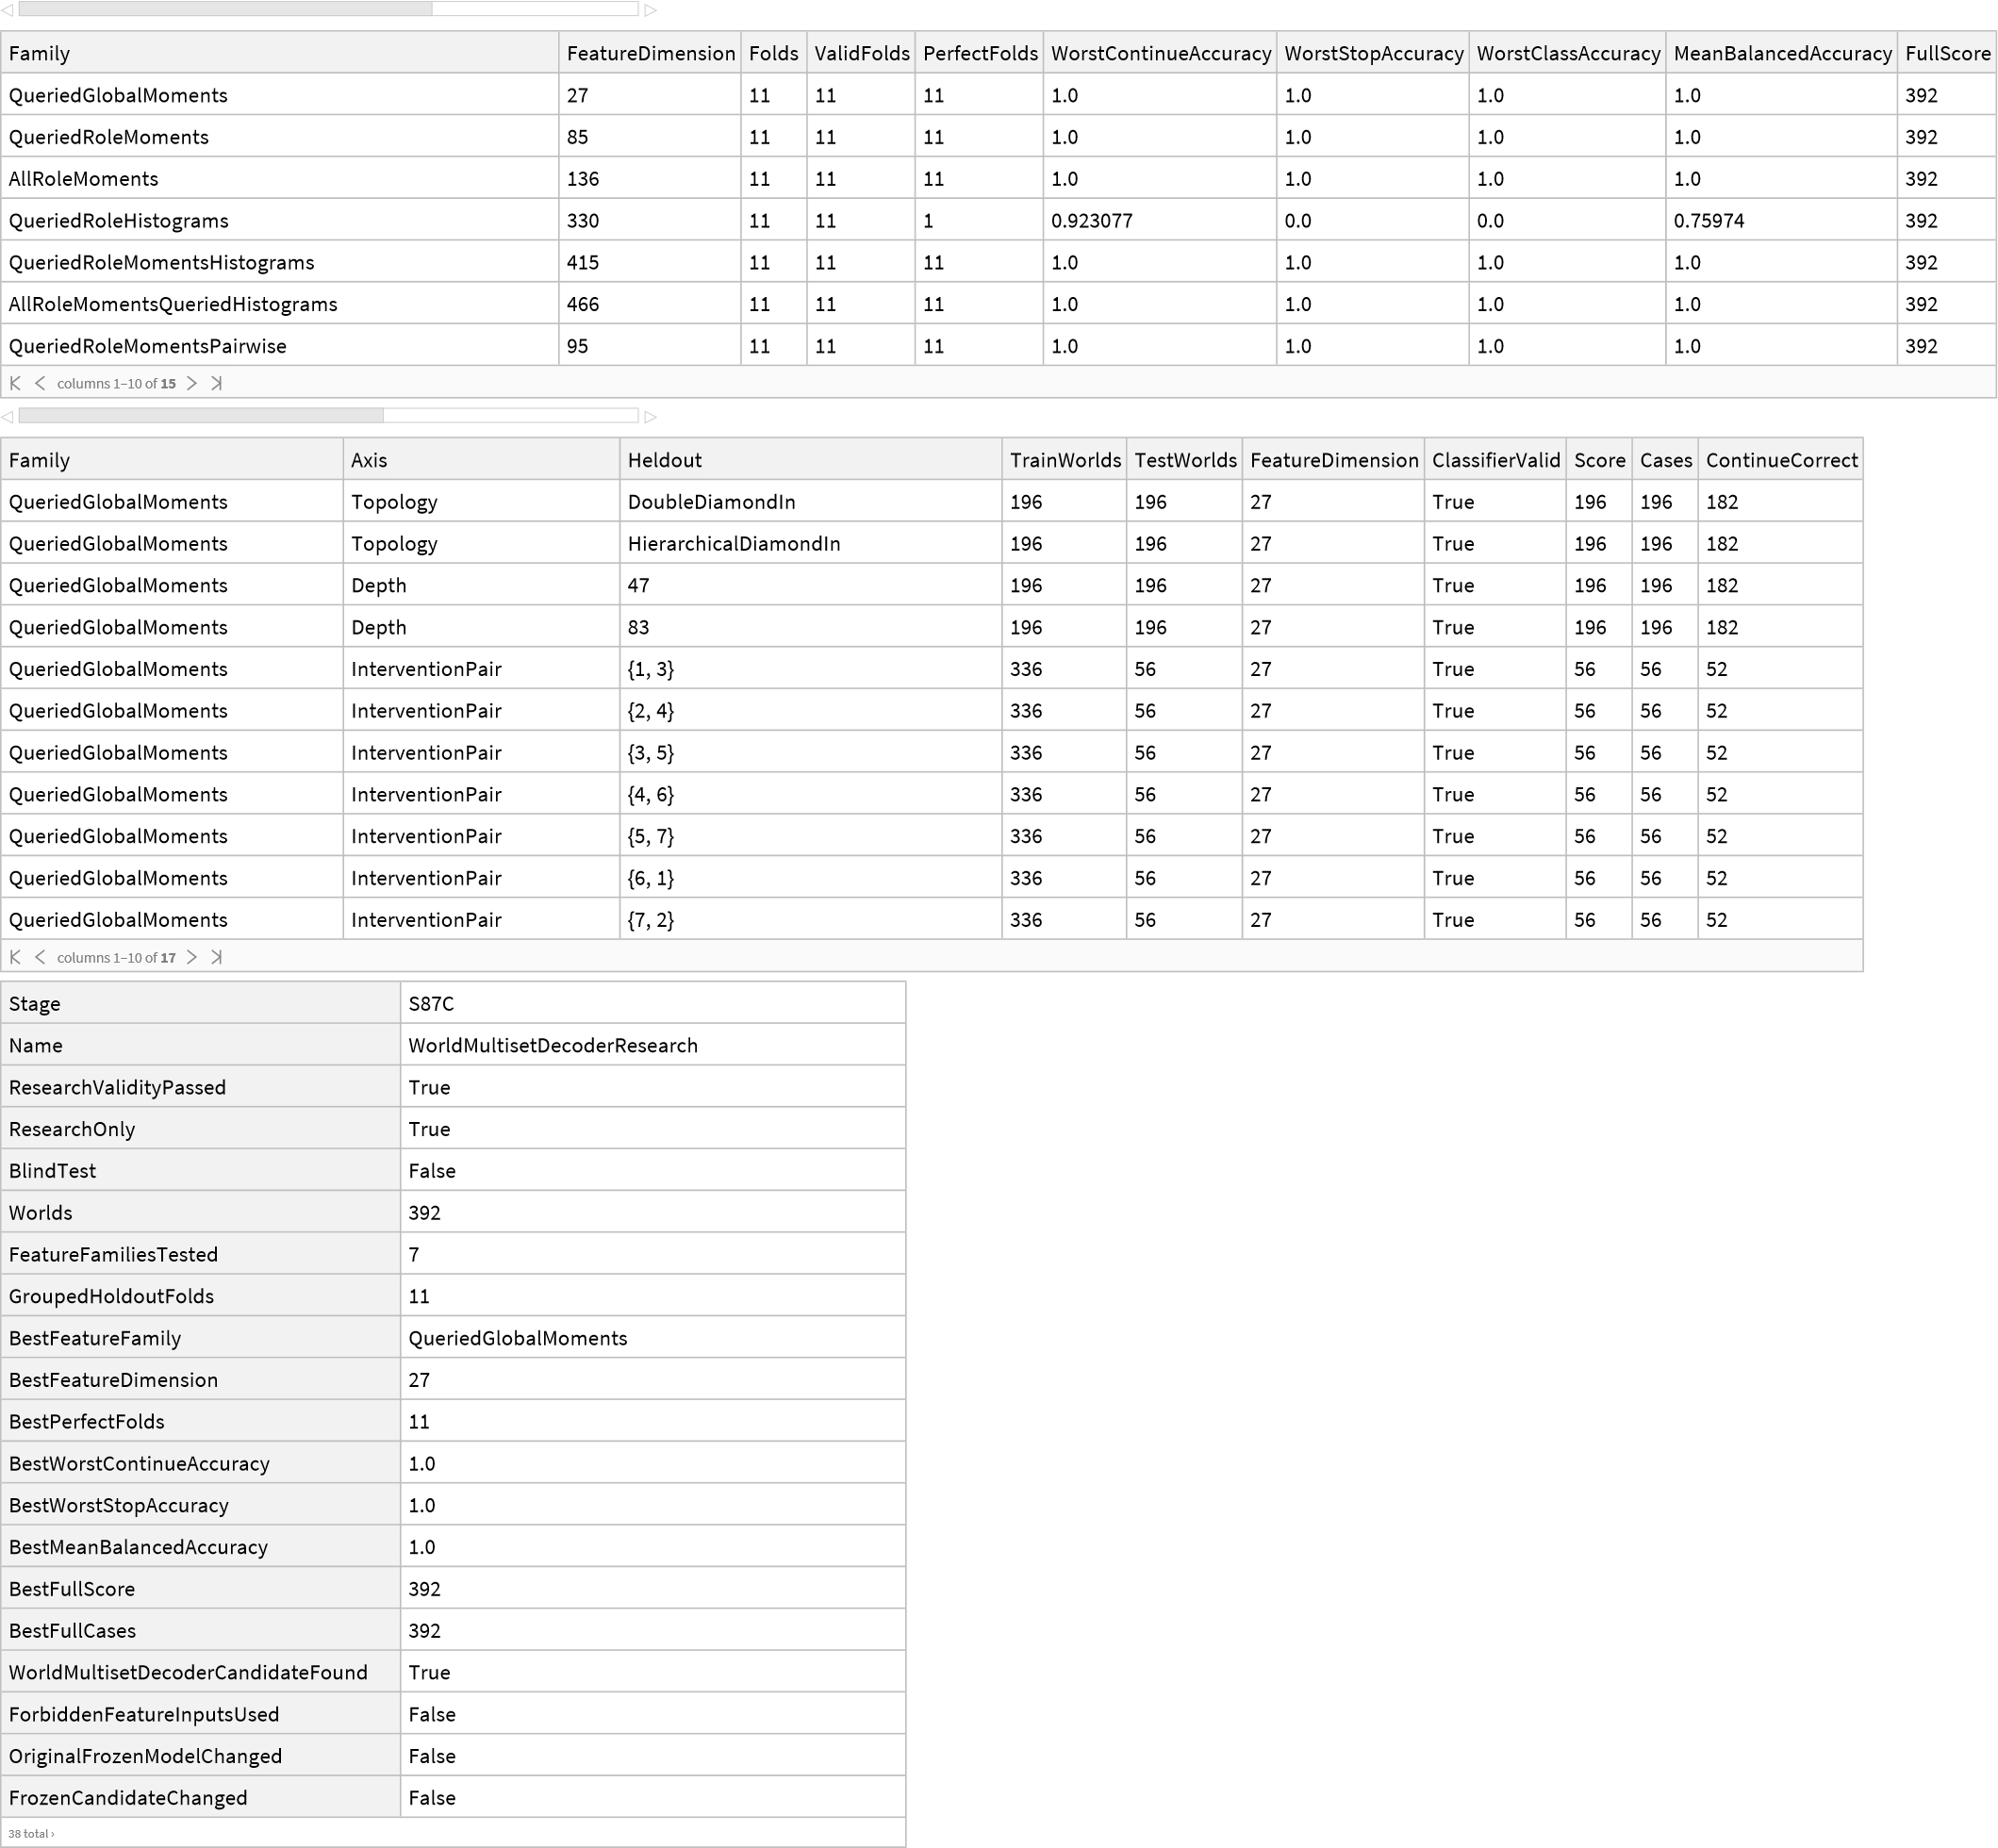

In [285]:
CodeStats87C[observations_List]:=Module[
{codes,a,b,delta,sum,product},
codes=Lookup[observations,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,17]]];
a=codes[[All,1]];
b=codes[[All,2]];
delta=Mod[a-b,33];
sum=Mod[a+b-2,33];
product=Mod[(a-1)(b-1),33];
{
Length[codes],
Length[DeleteDuplicates[codes]],
Total[a],Total[b],
Total[a^2],Total[b^2],
Min[a],Max[a],Min[b],Max[b],
Total[delta],Total[sum],Total[product],
Count[MapThread[SameQ,{a,b}],True],
Count[MapThread[Less,{a,b}],True],
Count[MapThread[Greater,{a,b}],True],
Total[Abs[a-b]]
}
];

CodeHistogram87C[observations_List]:=Module[{codes,a,b},
codes=Lookup[observations,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,66]]];
a=codes[[All,1]];
b=codes[[All,2]];
Join[Count[a,#]&/@Range[33],Count[b,#]&/@Range[33]]
];

PairwiseStats87C[observations_List]:=Module[
{codes,pairs,firstDistance,secondDistance,crossDistance},
codes=Lookup[observations,"Code",{}];
pairs=Subsets[codes,{2}];
If[Length[pairs]===0,Return[ConstantArray[0,10]]];
firstDistance=Abs[pairs[[All,1,1]]-pairs[[All,2,1]]];
secondDistance=Abs[pairs[[All,1,2]]-pairs[[All,2,2]]];
crossDistance=Abs[
(pairs[[All,1,1]]-pairs[[All,1,2]])-
(pairs[[All,2,1]]-pairs[[All,2,2]])
];
{
Length[pairs],
Total[firstDistance],Total[secondDistance],Total[crossDistance],
Min[firstDistance],Max[firstDistance],
Min[secondDistance],Max[secondDistance],
Count[firstDistance,0],Count[secondDistance,0]
}
];

SelectRoleObservations87C[
world_Association,role_String,queryRelatedOnly_
]:=Select[
world["Observations"],
And[
SameQ[#1["Role"],role],
If[TrueQ[queryRelatedOnly],TrueQ[#1["QueryBranchRelated"]],True]
]&
];

WorldVector87C[world_Association,family_String]:=Module[
{queriedObservations,queriedRoleObservations,allRoleObservations},
queriedObservations=Select[
world["Observations"],TrueQ[#1["QueryBranchRelated"]]&
];
queriedRoleObservations=Map[
SelectRoleObservations87C[world,#,True]&,
queriedRoles87C
];
allRoleObservations=Map[
SelectRoleObservations87C[world,#,False]&,
allRoles87C
];
Switch[
family,
"QueriedGlobalMoments",
Join[CodeStats87C[queriedObservations],PairwiseStats87C[queriedObservations]],
"QueriedRoleMoments",
Flatten[CodeStats87C/@queriedRoleObservations],
"AllRoleMoments",
Flatten[CodeStats87C/@allRoleObservations],
"QueriedRoleHistograms",
Flatten[CodeHistogram87C/@queriedRoleObservations],
"QueriedRoleMomentsHistograms",
Flatten@Join[
CodeStats87C/@queriedRoleObservations,
CodeHistogram87C/@queriedRoleObservations
],
"AllRoleMomentsQueriedHistograms",
Flatten@Join[
CodeStats87C/@allRoleObservations,
CodeHistogram87C/@queriedRoleObservations
],
"QueriedRoleMomentsPairwise",
Join[
Flatten[CodeStats87C/@queriedRoleObservations],
PairwiseStats87C[queriedObservations]
],
_,$Failed
]
];

BuildFeatureRows87C[worlds_List,family_String]:=Map[
Function[world,
<|
"Topology"->world["Topology"],
"Depth"->world["Depth"],
"InterventionPair"->world["InterventionPair"],
"Target"->world["Target"],
"Vector"->WorldVector87C[world,family]
|>
],
worlds
];

SplitFeatureRows87C[rows_List,fold_Association]:=Module[
{axis,value,test,train},
axis=fold["Axis"];
value=fold["Heldout"];
test=Select[rows,SameQ[#1[axis],value]&];
train=Select[rows,!SameQ[#1[axis],value]&];
<|"Train"->train,"Test"->test|>
];

BalancedTrainingRules87C[rows_List]:=Module[
{continueRows,stopRows,repeatCount,balancedStopRows},
continueRows=Select[rows,SameQ[#1["Target"],"Continue"]&];
stopRows=Select[rows,SameQ[#1["Target"],"Stop"]&];
If[
Length[continueRows]===0||Length[stopRows]===0,
Return[$Failed]
];
repeatCount=Ceiling[Length[continueRows]/Length[stopRows]];
balancedStopRows=Take[
Flatten[ConstantArray[stopRows,repeatCount],1],
Length[continueRows]
];
(#1["Vector"]->#1["Target"])&/@Join[continueRows,balancedStopRows]
];

ScorePredictions87C[rows_List,predictions_List]:=Module[
{targets,continuePositions,stopPositions,continueCorrect,stopCorrect},
targets=Lookup[rows,"Target"];
continuePositions=Flatten@Position[targets,"Continue"];
stopPositions=Flatten@Position[targets,"Stop"];
continueCorrect=Count[predictions[[continuePositions]],"Continue"];
stopCorrect=Count[predictions[[stopPositions]],"Stop"];
<|
"Score"->Count[MapThread[SameQ,{predictions,targets}],True],
"Cases"->Length[rows],
"ContinueCorrect"->continueCorrect,
"ContinueCases"->Length[continuePositions],
"StopCorrect"->stopCorrect,
"StopCases"->Length[stopPositions],
"ContinueAccuracy"->N[continueCorrect/Length[continuePositions]],
"StopAccuracy"->N[stopCorrect/Length[stopPositions]],
"BalancedAccuracy"->N@Mean[{
continueCorrect/Length[continuePositions],
stopCorrect/Length[stopPositions]
}]
|>
];

EvaluateDecoderFold87C[
rows_List,family_String,fold_Association
]:=Module[
{split,train,test,trainingRules,classifier,predictions,score},
split=SplitFeatureRows87C[rows,fold];
train=split["Train"];
test=split["Test"];
trainingRules=BalancedTrainingRules87C[train];
SeedRandom[870300+Length[train]+Length[test],Method->"MersenneTwister"];
classifier=Quiet@Check[
Classify[trainingRules,Method->"DecisionTree"],
$Failed
];
If[
SameQ[classifier,$Failed]||Head[classifier]=!=ClassifierFunction,
Return[<|
"Family"->family,"Axis"->fold["Axis"],"Heldout"->fold["Heldout"],
"TrainWorlds"->Length[train],"TestWorlds"->Length[test],
"ClassifierValid"->False,"Score"->0,"Cases"->Length[test],
"ContinueCorrect"->0,
"ContinueCases"->Count[test,row_/;SameQ[row["Target"],"Continue"]],
"StopCorrect"->0,
"StopCases"->Count[test,row_/;SameQ[row["Target"],"Stop"]],
"ContinueAccuracy"->0.,"StopAccuracy"->0.,"BalancedAccuracy"->0.,
"Perfect"->False
|>]
];
predictions=Quiet@Check[classifier/@Lookup[test,"Vector"],$Failed];
If[SameQ[predictions,$Failed],predictions=ConstantArray["Invalid",Length[test]]];
score=ScorePredictions87C[test,predictions];
Join[
<|
"Family"->family,
"Axis"->fold["Axis"],
"Heldout"->fold["Heldout"],
"TrainWorlds"->Length[train],
"TestWorlds"->Length[test],
"FeatureDimension"->Length[First[Lookup[train,"Vector"]]],
"ClassifierValid"->True
|>,
score,
<|"Perfect"->SameQ[score["Score"],score["Cases"]]|>
]
];

EvaluateDecoderFamily87C[worlds_List,family_String]:=Module[
{rows,foldRows,fullRules,fullClassifier,fullPredictions,fullScore,validFolds},
rows=BuildFeatureRows87C[worlds,family];
foldRows=EvaluateDecoderFold87C[rows,family,#]&/@foldSpecs87B;
fullRules=BalancedTrainingRules87C[rows];
SeedRandom[870399,Method->"MersenneTwister"];
fullClassifier=Quiet@Check[
Classify[fullRules,Method->"DecisionTree"],
$Failed
];
If[
SameQ[fullClassifier,$Failed]||Head[fullClassifier]=!=ClassifierFunction,
fullPredictions=ConstantArray["Invalid",Length[rows]],
fullPredictions=Quiet@Check[
fullClassifier/@Lookup[rows,"Vector"],
ConstantArray["Invalid",Length[rows]]
]
];
fullScore=ScorePredictions87C[rows,fullPredictions];
validFolds=Count[foldRows,row_/;TrueQ[row["ClassifierValid"]]];
<|
"Family"->family,
"FeatureDimension"->Length[First[Lookup[rows,"Vector"]]],
"Folds"->Length[foldRows],
"ValidFolds"->validFolds,
"PerfectFolds"->Count[foldRows,row_/;TrueQ[row["Perfect"]]],
"WorstContinueAccuracy"->Min[Lookup[foldRows,"ContinueAccuracy"]],
"WorstStopAccuracy"->Min[Lookup[foldRows,"StopAccuracy"]],
"WorstClassAccuracy"->Min@Join[
Lookup[foldRows,"ContinueAccuracy"],Lookup[foldRows,"StopAccuracy"]
],
"MeanBalancedAccuracy"->Mean[Lookup[foldRows,"BalancedAccuracy"]],
"FullScore"->fullScore["Score"],
"FullCases"->fullScore["Cases"],
"FullContinueCorrect"->fullScore["ContinueCorrect"],
"FullContinueCases"->fullScore["ContinueCases"],
"FullStopCorrect"->fullScore["StopCorrect"],
"FullStopCases"->fullScore["StopCases"],
"FoldRows"->foldRows,
"FullClassifier"->fullClassifier
|>
];

S87CDefinitionBundle[]:={
DownValues[CodeStats87C],DownValues[CodeHistogram87C],
DownValues[PairwiseStats87C],DownValues[SelectRoleObservations87C],
DownValues[WorldVector87C],DownValues[BuildFeatureRows87C],
DownValues[SplitFeatureRows87C],DownValues[BalancedTrainingRules87C],
DownValues[ScorePredictions87C],DownValues[EvaluateDecoderFold87C],
DownValues[EvaluateDecoderFamily87C]
};

definitionHashBeforeEvaluation87C=Hash[
S87CDefinitionBundle[],"SHA256","HexString"
];

familyResults87C=EvaluateDecoderFamily87C[
allWorlds87A,#
]&/@featureFamilies87C;

rankedResults87C=SortBy[
familyResults87C,
{
-#1["PerfectFolds"],
-#1["WorstClassAccuracy"],
-#1["MeanBalancedAccuracy"],
-#1["FullScore"],
#1["FeatureDimension"],
#1["Family"]
}&
];
bestResult87C=First[rankedResults87C];
bestFamily87C=bestResult87C["Family"];
bestFoldRows87C=bestResult87C["FoldRows"];

worldMultisetDecoderCandidateFound87C=And[
SameQ[bestResult87C["ValidFolds"],Length[foldSpecs87B]],
SameQ[bestResult87C["PerfectFolds"],Length[foldSpecs87B]],
SameQ[bestResult87C["WorstContinueAccuracy"],1.],
SameQ[bestResult87C["WorstStopAccuracy"],1.],
SameQ[bestResult87C["FullScore"],Length[allWorlds87A]]
];

modelHashAfter87C=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashAfter87C=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
coreHashAfter87C=Hash[CoreDefinitionBundle87[],"SHA256","HexString"];
canonicalizerHashAfter87C=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashAfter87C=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyHashAfter87C=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
originalS87DefinitionHashAfter87C=Hash[
S87TestDefinitionBundle[],"SHA256","HexString"
];
definitionHashAfterEvaluation87C=Hash[
S87CDefinitionBundle[],"SHA256","HexString"
];
protocolHashAfter87C=Hash[Normal[protocol87C],"SHA256","HexString"];
inputDataHashAfter87C=Hash[Normal[auditDataPayload87B],"SHA256","HexString"];
k33CandidateFileHashAfter87C=FileHash[k33CandidatePath87,"SHA256"];

coreUnchanged87C=SameQ[coreHashBefore87C,coreHashAfter87C];
deduplicationMechanismUnchanged87C=And[
TrueQ[coreUnchanged87C],
SameQ[
protocol87["TokenDeduplication"],
"DeleteDuplicatesAfterExactRoleCodePairing"
]
];

researchValidityPassed87C=And[
SameQ[Length[foldSpecs87B],11],
SameQ[Length[familyResults87C],Length[featureFamilies87C]],
And@@Map[
SameQ[#1["ValidFolds"],Length[foldSpecs87B]]&,
familyResults87C
],
SameQ[modelHashBefore87C,modelHashAfter87C],
SameQ[candidateHashBefore87C,candidateHashAfter87C],
TrueQ[coreUnchanged87C],
SameQ[canonicalizerHashBefore87C,canonicalizerHashAfter87C],
SameQ[interventionHashBefore87C,interventionHashAfter87C],
SameQ[topologyHashBefore87C,topologyHashAfter87C],
SameQ[
originalS87DefinitionHashBefore87C,originalS87DefinitionHashAfter87C
],
SameQ[definitionHashBeforeEvaluation87C,definitionHashAfterEvaluation87C],
SameQ[protocolHash87C,protocolHashAfter87C],
SameQ[inputDataHashBefore87C,inputDataHashAfter87C],
SameQ[k33CandidateFileHashBefore87C,k33CandidateFileHashAfter87C],
TrueQ[deduplicationMechanismUnchanged87C]
];

cert87C=<|
"Stage"->"S87C",
"Name"->"WorldMultisetDecoderResearch",
"ResearchValidityPassed"->researchValidityPassed87C,
"ResearchOnly"->True,
"BlindTest"->False,
"Worlds"->Length[allWorlds87A],
"FeatureFamiliesTested"->Length[featureFamilies87C],
"GroupedHoldoutFolds"->Length[foldSpecs87B],
"BestFeatureFamily"->bestFamily87C,
"BestFeatureDimension"->bestResult87C["FeatureDimension"],
"BestPerfectFolds"->bestResult87C["PerfectFolds"],
"BestWorstContinueAccuracy"->bestResult87C["WorstContinueAccuracy"],
"BestWorstStopAccuracy"->bestResult87C["WorstStopAccuracy"],
"BestMeanBalancedAccuracy"->bestResult87C["MeanBalancedAccuracy"],
"BestFullScore"->bestResult87C["FullScore"],
"BestFullCases"->bestResult87C["FullCases"],
"WorldMultisetDecoderCandidateFound"->worldMultisetDecoderCandidateFound87C,
"ForbiddenFeatureInputsUsed"->False,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore87C,modelHashAfter87C],
"FrozenCandidateChanged"->!SameQ[candidateHashBefore87C,candidateHashAfter87C],
"CoreChanged"->!TrueQ[coreUnchanged87C],
"CanonicalizerChanged"->!SameQ[
canonicalizerHashBefore87C,canonicalizerHashAfter87C
],
"InterventionChanged"->!SameQ[
interventionHashBefore87C,interventionHashAfter87C
],
"TopologyImplementationsChanged"->!SameQ[
topologyHashBefore87C,topologyHashAfter87C
],
"DeduplicationMechanismChanged"->!TrueQ[
deduplicationMechanismUnchanged87C
],
"CandidateFileChanged"->!SameQ[
k33CandidateFileHashBefore87C,k33CandidateFileHashAfter87C
],
"UsesRevealedS87Labels"->True,
"S87LabelsAppliedToFrozenModel"->False,
"DecoderResearchTrainingRun"->True,
"FrozenModelTrainingRun"->False,
"DecoderFamilySearchRun"->True,
"FrozenCandidateSearchRun"->False,
"FrozenPolicyEditApplied"->False,
"NewDecoderFrozen"->False,
"CandidateExported"->False,
"MayClaimNewBlindGeneralization"->False,
"Outcome"->Which[
!TrueQ[researchValidityPassed87C],
"S87C_INVALID_RESEARCH_AUDIT",
TrueQ[worldMultisetDecoderCandidateFound87C],
"S87C_WORLD_MULTISET_DECODER_CANDIDATE_FOUND_NOT_FROZEN",
True,
"S87C_NO_PERFECT_WORLD_MULTISET_DECODER_CANDIDATE"
],
"SuggestedNextStage"->If[
TrueQ[worldMultisetDecoderCandidateFound87C],
"S87D_FREEZE_DECODER_THEN_DESIGN_S88_BLIND",
"S87D_AUDIT_QUERY_LOCAL_SEMANTIC_SUFFICIENCY"
]
|>;

Column[{
Dataset[Map[KeyDrop[#,{"FoldRows","FullClassifier"}]&,familyResults87C]],
Dataset[bestFoldRows87C],
Dataset[{cert87C}]
}]


## S87D - Freeze and lock the S87C decoder

Run **only the next cell** in the current completed S87C kernel. Do not restart the kernel and do not run all cells. This stage freezes the already-selected decoder, verifies a binary export/import round trip, and does not generate or read any S88 blind-test data.


Export::jsonstrictencoding: Expression Rule cannot be exported as JSON.

Dataset[{<|Stage -> S87D, Name -> FreezeWorldMultisetDecoder, 
 
>     FreezeValidityPassed -> True, FeatureFamily -> QueriedGlobalMoments, 
 
>     FeatureDimension -> 27, DevelopmentWorlds -> 392, 
 
>     DevelopmentScoreBeforeExport -> 392, DevelopmentScoreAfterImport -> 392, 
 
>     GroupedHoldoutPerfectFolds -> 11, GroupedHoldoutFolds -> 11, 
 
>     FeatureParityPassed -> True, RoundTripPredictionParityPassed -> True, 
 
>     RoundTripScorePassed -> True, CandidateExported -> True, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      58972802749150077008917405397554671205379452291467020415243325096138419215761, 
 
>     ClassifierBinaryHash -> 
 
>      2b8861c03c8169571061a85c12644c6e30a11e8f8f15f5c69c6761215f4752f1, 
 
>     FeatureRuntimeFileHash -> 
 
>      56662785305507321337327468720377074558080341718112862515770942197395296305390, 
 
>     ProtocolHash -> 03d7a40eefdaec9d9fce599517d3663ba381d50218bfe4934580bd22ca31b86c, 
 
>     OriginalFrozenModelChanged -> False, OriginalK33CandidateChanged -> False, 
 
>     OriginalFrozenPolicyChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionChanged -> False, 
 
>     TopologyImplementationsChanged -> False, DeduplicationMechanismChanged -> False, 
 
>     OuterDecoderAdded -> True, UsesRevealedS87Labels -> True, 
 
>     MayClaimBlindGeneralization -> False, S88DataReadBeforeFreeze -> False, 
 
>     S88BlindTestRun -> False, ReadyForS88 -> True, 
 
>     Outcome -> S87D_DECODER_FROZEN_AND_LOCKED_READY_FOR_S88|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 34], 
 
>    1], <||>]
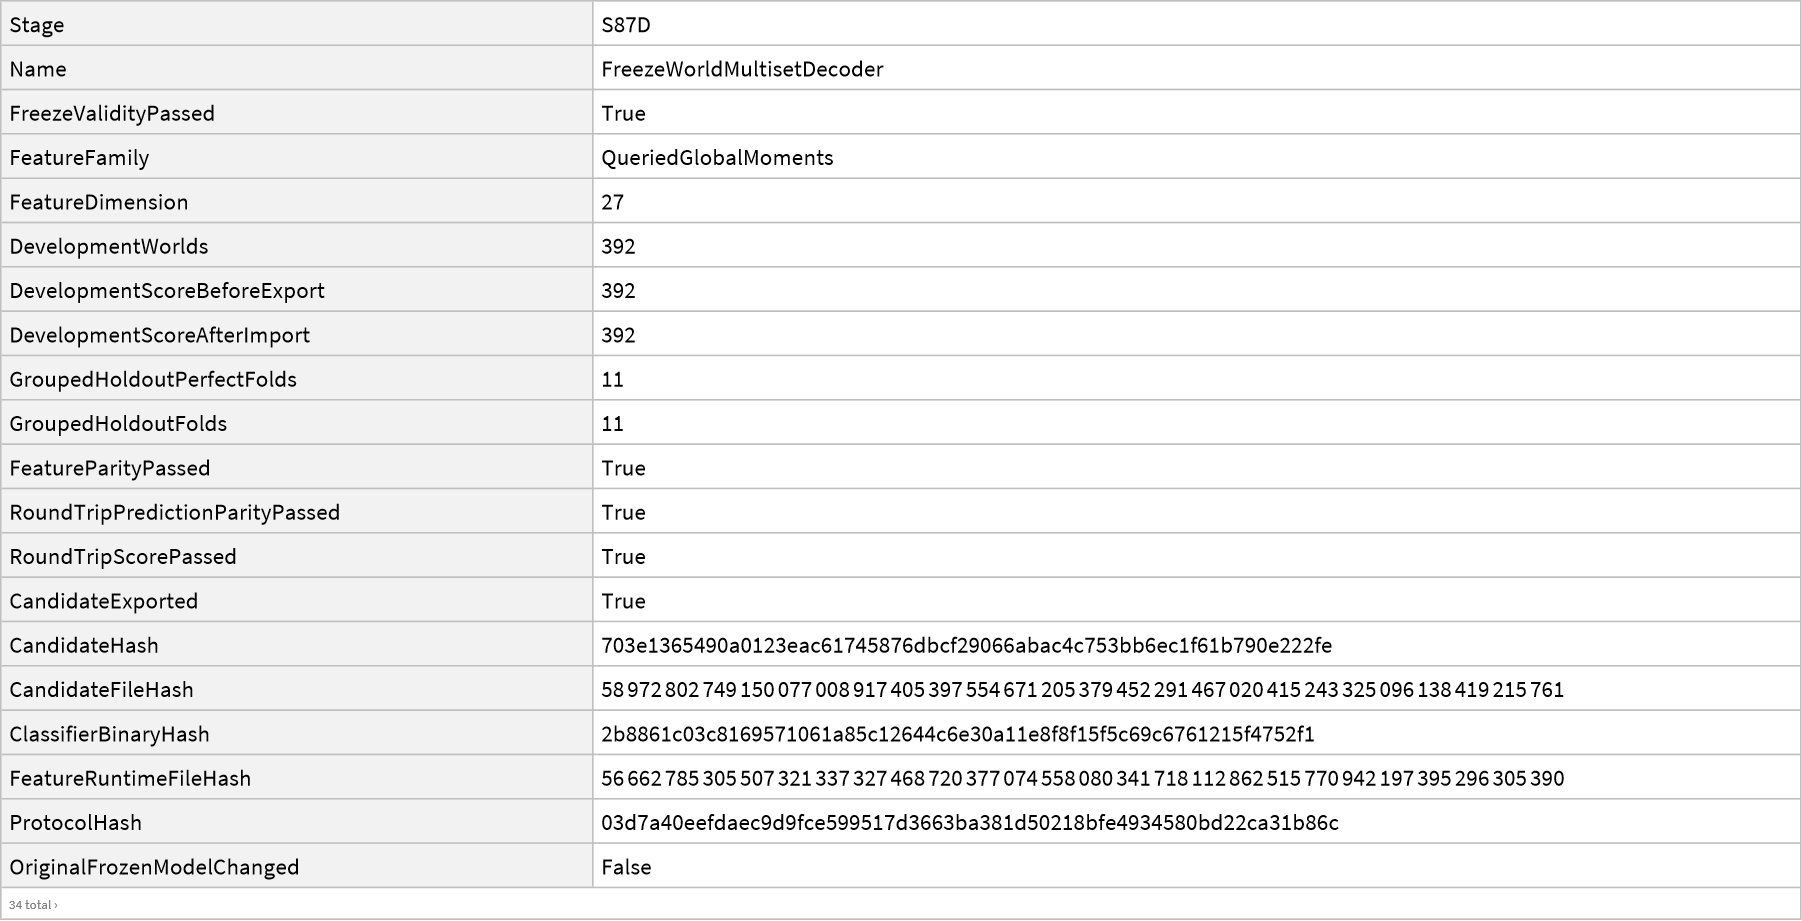

In [368]:
(* TCCT S87D CELL
   Freeze the already-selected S87C world-multiset decoder before S88 exists.
   Run this cell only in the current, completed S87C kernel. *)

s87DStateAvailable = And[
  ValueQ[allWorlds87A],
  ValueQ[cert87A],
  ValueQ[cert87B],
  ValueQ[cert87C],
  ValueQ[bestResult87C],
  ListQ[allWorlds87A],
  SameQ[Length[allWorlds87A], 392],
  TrueQ[cert87A["AuditValidityPassed"]],
  TrueQ[cert87B["ResearchValidityPassed"]],
  TrueQ[cert87C["ResearchValidityPassed"]],
  TrueQ[cert87C["WorldMultisetDecoderCandidateFound"]],
  SameQ[cert87C["Outcome"],
    "S87C_WORLD_MULTISET_DECODER_CANDIDATE_FOUND_NOT_FROZEN"],
  SameQ[bestResult87C["Family"], "QueriedGlobalMoments"],
  SameQ[bestResult87C["FeatureDimension"], 27],
  SameQ[bestResult87C["PerfectFolds"], 11],
  SameQ[bestResult87C["FullScore"], 392],
  Head[bestResult87C["FullClassifier"]] === ClassifierFunction
];

If[
  !TrueQ[s87DStateAvailable],
  Print["S87D aborted: the completed and valid S87C runtime state is missing."];
  Print["Return to TCCT_S87A_SevenBranchFailureAudit.ipynb and run S87A-S87C first."];
  Abort[]
];

expectedFrozenModelHash87D =
  "d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash87D =
  "2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";

s87DRuntimePath =
  "E:\\engine_wolf\\TCCT_S87D_FrozenDecoderRuntime.wl";
s87DCandidatePath =
  "E:\\engine_wolf\\TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
s87DMetadataPath =
  "E:\\engine_wolf\\TCCT_S87D_FrozenWorldMultisetDecoder_Metadata.wl";
s87DCertificatePath =
  "E:\\engine_wolf\\TCCT_S87D_FreezeCertificate.json";

If[
  !FileExistsQ[s87DRuntimePath],
  Print["S87D aborted: frozen feature runtime file is missing: ", s87DRuntimePath];
  Abort[]
];

modelHashBefore87D = Hash[Normal[frozen75D], "SHA256", "HexString"];
candidateHashBefore87D =
  Hash[Normal[frozenCandidate86E], "SHA256", "HexString"];
coreHashBefore87D = Hash[CoreDefinitionBundle87[], "SHA256", "HexString"];
canonicalizerHashBefore87D = Hash[
  {
    DownValues[FindPrivateDiamond79B],
    DownValues[CanonicalizePrivateDiamonds79B],
    DownValues[CanonicalCase79B]
  },
  "SHA256", "HexString"
];
interventionHashBefore87D = Hash[
  {
    DownValues[LocalMediatorSources82],
    DownValues[FullSemanticPatch82],
    DownValues[LocalMediatorPatch82],
    DownValues[ReferenceAction82]
  },
  "SHA256", "HexString"
];
topologyHashBefore87D = Hash[
  {DownValues[DoubleDiamondIn79], DownValues[HierarchicalDiamondIn80]},
  "SHA256", "HexString"
];
s87DefinitionHashBefore87D = Hash[
  S87TestDefinitionBundle[], "SHA256", "HexString"
];
s87CDefinitionHashBefore87D = Hash[
  S87CDefinitionBundle[], "SHA256", "HexString"
];
s87CInputDataHashBefore87D = Hash[
  Normal[auditDataPayload87B], "SHA256", "HexString"
];
k33CandidateFileHashBefore87D = FileHash[k33CandidatePath87, "SHA256"];
s87DRuntimeFileHashBefore = FileHash[s87DRuntimePath, "SHA256"];

Get[s87DRuntimePath];

s87DFeatureDefinitionHashBefore = Hash[
  TCCTFrozenFeatureDefinitionBundleS87D[], "SHA256", "HexString"
];

s87CVectorsForFreeze =
  (WorldVector87C[#, "QueriedGlobalMoments"] &) /@ allWorlds87A;
s87DVectorsForFreeze = TCCTWorldVectorS87D /@ allWorlds87A;
s87DFeatureParityPassed = SameQ[s87CVectorsForFreeze, s87DVectorsForFreeze];
s87DFeatureDimensionsPassed = And @@ (
  Function[vector, VectorQ[vector, IntegerQ] && Length[vector] === 27] /@
    s87DVectorsForFreeze
);

s87DClassifier = bestResult87C["FullClassifier"];
s87DTargets = Lookup[allWorlds87A, "Target"];
s87DPredictionsBeforeExport = Quiet@Check[
  s87DClassifier /@ s87DVectorsForFreeze,
  $Failed
];
s87DScoreBeforeExport = If[
  ListQ[s87DPredictionsBeforeExport],
  ScorePredictions87C[allWorlds87A, s87DPredictionsBeforeExport],
  $Failed
];

If[
  !TrueQ[s87DFeatureParityPassed] ||
  !TrueQ[s87DFeatureDimensionsPassed] ||
  !AssociationQ[s87DScoreBeforeExport] ||
  !SameQ[s87DScoreBeforeExport["Score"], 392] ||
  !SameQ[s87DScoreBeforeExport["ContinueCorrect"],
    s87DScoreBeforeExport["ContinueCases"]] ||
  !SameQ[s87DScoreBeforeExport["StopCorrect"],
    s87DScoreBeforeExport["StopCases"]],
  Print["S87D aborted: feature parity or pre-export prediction lock failed."];
  Abort[]
];

s87DClassifierBinary = BinarySerialize[s87DClassifier];
s87DClassifierBinaryHash = Hash[
  s87DClassifierBinary, "SHA256", "HexString"
];

s87DProtocol = <|
  "Stage" -> "S87D",
  "Name" -> "FreezeWorldMultisetDecoder",
  "Purpose" -> "FreezeSelectedS87CDecoderBeforeS88",
  "ResearchSourceStage" -> "S87C",
  "UsesRevealedS87Labels" -> True,
  "BlindTest" -> False,
  "S88DesignedBeforeFreeze" -> False,
  "S88DataAvailableToFreeze" -> False,
  "S88BlindTestRun" -> False,
  "FeatureFamily" -> "QueriedGlobalMoments",
  "FeatureDimension" -> 27,
  "FeatureInputs" -> {"QueryBranchRelated", "Code"},
  "ForbiddenFeatureInputs" -> {
    "Topology", "Depth", "InterventionPair", "Answer",
    "GraphCondition", "Target"
  },
  "Classifier" -> "FrozenBalancedDecisionTree",
  "OriginalTrainingSeed" -> 870399,
  "TrainingBalance" -> "StopRowsRepeatedToMatchContinueRows",
  "CoreEditApplied" -> False,
  "OriginalFrozenPolicyEditApplied" -> False,
  "OuterDecoderAdded" -> True,
  "CandidateSearchRun" -> False,
  "DecoderRetrainedInS87D" -> False
|>;
s87DProtocolHash = Hash[
  Normal[s87DProtocol], "SHA256", "HexString"
];

s87DCandidatePayload = <|
  "Stage" -> "S87D",
  "Name" -> "FrozenWorldMultisetDecoder",
  "FrozenBeforeS88" -> True,
  "ResearchSourceStage" -> "S87C",
  "FeatureFamily" -> "QueriedGlobalMoments",
  "FeatureDimension" -> 27,
  "FeatureNames" -> TCCTFeatureNamesS87D[],
  "FeatureInputs" -> {"QueryBranchRelated", "Code"},
  "K" -> 33,
  "BaseFrozenModelHash" -> modelHashBefore87D,
  "BaseK33CandidateHash" -> candidateHashBefore87D,
  "S87CInputDataHash" -> s87CInputDataHashBefore87D,
  "S87CDefinitionHash" -> s87CDefinitionHashBefore87D,
  "FeatureRuntimeFileName" -> FileNameTake[s87DRuntimePath],
  "FeatureRuntimeFileHash" -> s87DRuntimeFileHashBefore,
  "FeatureDefinitionHash" -> s87DFeatureDefinitionHashBefore,
  "ClassifierMethod" -> "DecisionTree",
  "ClassifierSeed" -> 870399,
  "ClassifierBinary" -> s87DClassifierBinary,
  "ClassifierBinaryHash" -> s87DClassifierBinaryHash,
  "DevelopmentWorlds" -> 392,
  "DevelopmentScore" -> s87DScoreBeforeExport["Score"],
  "DevelopmentContinueCorrect" ->
    s87DScoreBeforeExport["ContinueCorrect"],
  "DevelopmentContinueCases" ->
    s87DScoreBeforeExport["ContinueCases"],
  "DevelopmentStopCorrect" -> s87DScoreBeforeExport["StopCorrect"],
  "DevelopmentStopCases" -> s87DScoreBeforeExport["StopCases"],
  "GroupedHoldoutFolds" -> 11,
  "GroupedHoldoutPerfectFolds" -> 11,
  "UsesRevealedS87Labels" -> True,
  "MayClaimBlindGeneralization" -> False,
  "S88DataReadBeforeFreeze" -> False,
  "ProtocolHash" -> s87DProtocolHash,
  "WolframVersion" -> $Version,
  "SystemID" -> $SystemID
|>;
s87DCandidateHash = Hash[
  Normal[s87DCandidatePayload], "SHA256", "HexString"
];
frozenDecoder87D = Append[
  s87DCandidatePayload,
  "CandidateHash" -> s87DCandidateHash
];

s87DExistingCandidateCompatible = False;
s87DCandidateCreatedThisRun = !FileExistsQ[s87DCandidatePath];
If[
  FileExistsQ[s87DCandidatePath],
  s87DExistingCandidate = Quiet@Check[
    Import[s87DCandidatePath, "WXF"], $Failed
  ];
  s87DExistingCandidateCompatible = And[
    AssociationQ[s87DExistingCandidate],
    SameQ[
      Lookup[s87DExistingCandidate, "CandidateHash", $Failed],
      s87DCandidateHash
    ]
  ];
  If[
    !TrueQ[s87DExistingCandidateCompatible],
    Print["S87D aborted: an incompatible candidate file already exists."];
    Print[s87DCandidatePath];
    Abort[]
  ],
  s87DExportResult = Quiet@Check[
    Export[s87DCandidatePath, frozenDecoder87D, "WXF"],
    $Failed
  ];
  If[SameQ[s87DExportResult, $Failed],
    Print["S87D aborted: candidate export failed."];
    Abort[]
  ]
];

s87DLoadedDecoder = TCCTLoadFrozenDecoderS87D[s87DCandidatePath];
s87DPredictionsAfterImport = If[
  AssociationQ[s87DLoadedDecoder],
  (TCCTPredictWorldS87D[#, s87DLoadedDecoder] &) /@ allWorlds87A,
  $Failed
];
s87DScoreAfterImport = If[
  ListQ[s87DPredictionsAfterImport],
  ScorePredictions87C[allWorlds87A, s87DPredictionsAfterImport],
  $Failed
];

s87DRoundTripPredictionParityPassed = SameQ[
  s87DPredictionsBeforeExport,
  s87DPredictionsAfterImport
];
s87DRoundTripScorePassed = And[
  AssociationQ[s87DScoreAfterImport],
  SameQ[s87DScoreAfterImport["Score"], 392],
  SameQ[s87DScoreAfterImport["ContinueCorrect"],
    s87DScoreAfterImport["ContinueCases"]],
  SameQ[s87DScoreAfterImport["StopCorrect"],
    s87DScoreAfterImport["StopCases"]]
];

If[
  !TrueQ[s87DRoundTripPredictionParityPassed] ||
  !TrueQ[s87DRoundTripScorePassed] ||
  !AssociationQ[s87DLoadedDecoder],
  If[
    TrueQ[s87DCandidateCreatedThisRun] && FileExistsQ[s87DCandidatePath],
    DeleteFile[s87DCandidatePath]
  ];
  Print["S87D aborted: exported decoder failed round-trip verification."];
  Abort[]
];

modelHashAfter87D = Hash[Normal[frozen75D], "SHA256", "HexString"];
candidateHashAfter87D =
  Hash[Normal[frozenCandidate86E], "SHA256", "HexString"];
coreHashAfter87D = Hash[CoreDefinitionBundle87[], "SHA256", "HexString"];
canonicalizerHashAfter87D = Hash[
  {
    DownValues[FindPrivateDiamond79B],
    DownValues[CanonicalizePrivateDiamonds79B],
    DownValues[CanonicalCase79B]
  },
  "SHA256", "HexString"
];
interventionHashAfter87D = Hash[
  {
    DownValues[LocalMediatorSources82],
    DownValues[FullSemanticPatch82],
    DownValues[LocalMediatorPatch82],
    DownValues[ReferenceAction82]
  },
  "SHA256", "HexString"
];
topologyHashAfter87D = Hash[
  {DownValues[DoubleDiamondIn79], DownValues[HierarchicalDiamondIn80]},
  "SHA256", "HexString"
];
s87DefinitionHashAfter87D = Hash[
  S87TestDefinitionBundle[], "SHA256", "HexString"
];
s87CDefinitionHashAfter87D = Hash[
  S87CDefinitionBundle[], "SHA256", "HexString"
];
s87CInputDataHashAfter87D = Hash[
  Normal[auditDataPayload87B], "SHA256", "HexString"
];
k33CandidateFileHashAfter87D = FileHash[k33CandidatePath87, "SHA256"];
s87DRuntimeFileHashAfter = FileHash[s87DRuntimePath, "SHA256"];
s87DFeatureDefinitionHashAfter = Hash[
  TCCTFrozenFeatureDefinitionBundleS87D[], "SHA256", "HexString"
];
s87DCandidateFileHash = FileHash[s87DCandidatePath, "SHA256"];
deduplicationMechanismUnchanged87D = And[
  SameQ[
    protocol87["TokenDeduplication"],
    "DeleteDuplicatesAfterExactRoleCodePairing"
  ],
  SameQ[coreHashBefore87D, coreHashAfter87D]
];

s87DIntegrityPassed = And[
  SameQ[modelHashBefore87D, expectedFrozenModelHash87D],
  SameQ[candidateHashBefore87D, expectedK33CandidateHash87D],
  SameQ[modelHashBefore87D, modelHashAfter87D],
  SameQ[candidateHashBefore87D, candidateHashAfter87D],
  SameQ[coreHashBefore87D, coreHashAfter87D],
  SameQ[canonicalizerHashBefore87D, canonicalizerHashAfter87D],
  SameQ[interventionHashBefore87D, interventionHashAfter87D],
  SameQ[topologyHashBefore87D, topologyHashAfter87D],
  SameQ[s87DefinitionHashBefore87D, s87DefinitionHashAfter87D],
  SameQ[s87CDefinitionHashBefore87D, s87CDefinitionHashAfter87D],
  SameQ[s87CInputDataHashBefore87D, s87CInputDataHashAfter87D],
  SameQ[k33CandidateFileHashBefore87D, k33CandidateFileHashAfter87D],
  SameQ[s87DRuntimeFileHashBefore, s87DRuntimeFileHashAfter],
  SameQ[
    s87DFeatureDefinitionHashBefore,
    s87DFeatureDefinitionHashAfter
  ],
  TrueQ[deduplicationMechanismUnchanged87D],
  TrueQ[s87DFeatureParityPassed],
  TrueQ[s87DFeatureDimensionsPassed],
  TrueQ[s87DRoundTripPredictionParityPassed],
  TrueQ[s87DRoundTripScorePassed],
  AssociationQ[s87DLoadedDecoder]
];

s87DMetadata = KeyDrop[frozenDecoder87D, {"ClassifierBinary"}];
Put[s87DMetadata, s87DMetadataPath];

cert87D = <|
  "Stage" -> "S87D",
  "Name" -> "FreezeWorldMultisetDecoder",
  "FreezeValidityPassed" -> s87DIntegrityPassed,
  "FeatureFamily" -> "QueriedGlobalMoments",
  "FeatureDimension" -> 27,
  "DevelopmentWorlds" -> 392,
  "DevelopmentScoreBeforeExport" -> s87DScoreBeforeExport["Score"],
  "DevelopmentScoreAfterImport" -> s87DScoreAfterImport["Score"],
  "GroupedHoldoutPerfectFolds" -> 11,
  "GroupedHoldoutFolds" -> 11,
  "FeatureParityPassed" -> s87DFeatureParityPassed,
  "RoundTripPredictionParityPassed" ->
    s87DRoundTripPredictionParityPassed,
  "RoundTripScorePassed" -> s87DRoundTripScorePassed,
  "CandidateExported" -> FileExistsQ[s87DCandidatePath],
  "CandidateHash" -> s87DCandidateHash,
  "CandidateFileHash" -> s87DCandidateFileHash,
  "ClassifierBinaryHash" -> s87DClassifierBinaryHash,
  "FeatureRuntimeFileHash" -> s87DRuntimeFileHashAfter,
  "ProtocolHash" -> s87DProtocolHash,
  "OriginalFrozenModelChanged" ->
    !SameQ[modelHashBefore87D, modelHashAfter87D],
  "OriginalK33CandidateChanged" ->
    !SameQ[candidateHashBefore87D, candidateHashAfter87D],
  "OriginalFrozenPolicyChanged" ->
    !SameQ[candidateHashBefore87D, candidateHashAfter87D],
  "CoreChanged" -> !SameQ[coreHashBefore87D, coreHashAfter87D],
  "CanonicalizerChanged" ->
    !SameQ[canonicalizerHashBefore87D, canonicalizerHashAfter87D],
  "InterventionChanged" ->
    !SameQ[interventionHashBefore87D, interventionHashAfter87D],
  "TopologyImplementationsChanged" ->
    !SameQ[topologyHashBefore87D, topologyHashAfter87D],
  "DeduplicationMechanismChanged" ->
    !TrueQ[deduplicationMechanismUnchanged87D],
  "OuterDecoderAdded" -> True,
  "UsesRevealedS87Labels" -> True,
  "MayClaimBlindGeneralization" -> False,
  "S88DataReadBeforeFreeze" -> False,
  "S88BlindTestRun" -> False,
  "ReadyForS88" -> s87DIntegrityPassed,
  "Outcome" -> If[
    TrueQ[s87DIntegrityPassed],
    "S87D_DECODER_FROZEN_AND_LOCKED_READY_FOR_S88",
    "S87D_FREEZE_INVALID"
  ]
|>;

Export[s87DCertificatePath, Normal[cert87D], "RawJSON"];
Dataset[{cert87D}]
